# Trabajo Práctico Integrador - Ciencia de Datos
Integrantes: [Tomas Miqueleiz,Sebastian Fell,Marcos Palacios,Tarnoski Christian]
Asignatura: Licenciatura en Ciencia de Datos - UGR

## Entrega 1: Formulación del problema y carga de datos

### A. Comprensión del Negocio (Business Understanding)

Siguiendo la metodología CRISP-DM, la fase inicial se centra en comprender los objetivos del proyecto desde una perspectiva de negocio.

**1.1. Determinar los objetivos del negocio**
El objetivo principal es analizar la estructura y distribución de la riqueza dentro del aparato estatal del Gobierno de la Ciudad Autónoma de Buenos Aires (CABA). Buscamos comprender, desde una perspectiva de transparencia gubernamental, cómo se componen los patrimonios de los funcionarios públicos y si existen concentraciones de riqueza asociadas al nivel de poder político.

**1.2. Evaluar la situación**
* **Recursos y Datos:** Contamos con las Declaraciones Juradas Patrimoniales públicas provistas por el Portal de Datos Abiertos de la Ciudad (BA Data).
* **Supuestos y Restricciones:** Asumimos la veracidad legal de las DDJJ. La principal restricción técnica radicará en el tratamiento de los campos vacíos (nulos), los cuales en este contexto de negocio no representan un error de sistema, sino la ausencia de posesión de un bien determinado por parte del funcionario.

**1.3. Determinar las metas de la minería de datos**
Traducir los objetivos del negocio en metas técnicas de datos:
* Cuantificar la riqueza total declarada consolidando múltiples variables de activos (inmuebles, acciones, efectivo) en una única métrica de "Patrimonio Total".
* Identificar variables correlacionadas con los patrimonios más altos (Ej: Ministerios específicos o rangos jerárquicos).

**1.4. Preguntas Analíticas**
1. ¿Cuáles son las jurisdicciones o ministerios que concentran a los funcionarios con el mayor patrimonio promedio?
2. ¿Existe una brecha patrimonial medible y significativa entre los funcionarios catalogados como "Autoridad Superior" frente a los cargos subordinados?
3. ¿Cuál es la distribución del tipo de riqueza (inmuebles vs. activos financieros/depósitos) en la clase política porteña?

### B. Comprensión de los Datos (Data Understanding)

Esta fase comienza con la recolección inicial y procede con la exploración para familiarizarse con los datos y detectar problemas de calidad.

In [ ]:
#@title Importacion de librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

**2.1. Recolectar los Datos Iniciales**
Se ha adquirido el dataset oficial de las Declaraciones Juradas de los funcionarios del GCABA. Procedemos a su carga utilizando la librería Pandas.

In [ ]:
!mkdir -p ddjj
!wget -O ddjj/actas-notariales-compra-venta-inmuebles-hipotecas.csv "https://data.buenosaires.gob.ar/sl/dataset/mercado-inmobiliario/resource/1f0580e0-9e91-49c3-9ecc-f22217efa042/download"

--2026-06-20 22:53:33--  https://data.buenosaires.gob.ar/sl/dataset/mercado-inmobiliario/resource/1f0580e0-9e91-49c3-9ecc-f22217efa042/download
Resolving data.buenosaires.gob.ar (data.buenosaires.gob.ar)... 200.16.89.208
Connecting to data.buenosaires.gob.ar (data.buenosaires.gob.ar)|200.16.89.208|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://cdn.buenosaires.gob.ar/datosabiertos/datasets/instituto-de-vivienda/mercado-inmobiliario/actas-notariales-compra-venta-inmuebles-hipotecas.csv [following]
--2026-06-20 22:53:34--  https://cdn.buenosaires.gob.ar/datosabiertos/datasets/instituto-de-vivienda/mercado-inmobiliario/actas-notariales-compra-venta-inmuebles-hipotecas.csv
Resolving cdn.buenosaires.gob.ar (cdn.buenosaires.gob.ar)... 200.16.89.97
Connecting to cdn.buenosaires.gob.ar (cdn.buenosaires.gob.ar)|200.16.89.97|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 619005 (604K) [text/csv]
Saving to: ‘ddjj/actas-notariales-c

In [ ]:
# Carga del dataset
df_ddjj = pd.read_csv('/content/ddjj/actas-notariales-compra-venta-inmuebles-hipotecas.csv', sep=';')
print(f"Cantidad de registros (funcionarios): {df_ddjj.shape[0]}")
print(f"Cantidad de atributos (columnas): {df_ddjj.shape[1]}\n")

print("--- Tipos de datos por atributo ---")
df_ddjj.info()

Cantidad de registros (funcionarios): 2468
Cantidad de atributos (columnas): 21

--- Tipos de datos por atributo ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2468 entries, 0 to 2467
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   fechapresentacion         2468 non-null   object 
 1   jurisdiccion              2468 non-null   object 
 2   nombre                    2461 non-null   object 
 3   usuariosade               2468 non-null   object 
 4   cuil                      2468 non-null   int64  
 5   cargo                     2468 non-null   object 
 6   autoridad_superior        2456 non-null   object 
 7   tipoddjj                  2468 non-null   object 
 8   djratificada              27 non-null     object 
 9   sade_gedo_nro_ratificada  40 non-null     object 
 10  sadegedonumero            2468 non-null   object 
 11  cant_hijos                2455 non-null   float64
 12  t

**2.2. Exploración de los Datos**
Realizamos una primera aproximación visual a los registros.

In [ ]:
# Visualizamos los primeros 5 registros
display(df_ddjj.head())

,fechapresentacion,jurisdiccion,nombre,usuariosade,cuil,cargo,autoridad_superior,tipoddjj,djratificada,sade_gedo_nro_ratificada,...,cant_hijos,total_acciones,total_b_inmuebles,total_b_muebles,total_bonos,total_depositos,total_dinero_efectivo,total_dinero_electronico,total_fondos,total_titulos
0,2023-01-02,JEFATURA DE GABINETE DE MINISTROS,MARIA Marcela Jarvis,MARCELAJARVIS,27323241002,DIRECTOR GENERAL O EQUIVALENTE DEL PODER EJECU...,NO,Inicial,NaN,NaN,...,0.0,0.0,1896312.0,210000.0,0.0,494.0,250000.0,0.0,0.0,0.0
1,2023-01-02,MINISTERIO DE SALUD,Marco Roman Fidalgo,MFIDALGO,23268794069,NO APLICA,NO,Inicial,NaN,NaN,...,0.0,0.0,4.0,1400000.0,0.0,39354375.0,500000.0,0.0,0.0,0.0
2,2023-01-03,MINISTERIO DE EDUCACIÃ“N,Jorge Luis Silva,SILVAJL,20044384680,INTEGRANTE DE COMISIÃ“N EVALUADORA O DE COMIS...,NO,Inicial,NaN,NaN,...,7.0,0.0,31995000.0,1950000.0,0.0,4084191.0,7720.0,0.0,0.0,0.0
3,2023-01-04,MINISTERIO DE DESARROLLO ECONÃ“MICO Y PRODUCCIÃ“N,Federico Carlos Rebora,REBORAF,20202507701,NO APLICA,NO,ActualizaciÃ³n,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,100000.0,0.0,0.0,0.0
4,2023-01-05,MINISTERIO DE ESPACIO PÃšBLICO E HIGIENE URBANA,Ana Rita Sallaberry,SALLABERRYAR,27369173125,DIRECTOR GENERAL/ DIRECTOR DE LA PROCURACIÃ“N ...,SI,Final,NaN,NaN,...,0.0,0.0,0.0,1400000.0,0.0,0.0,5142.0,0.0,0.0,0.0


Inspeccionando los valores y tipos de datos podemos observar que:

- Las 14 variables tipo **float64** (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` `cant_hijos`, `total_acciones`, `total_b_inmuebles`, `total_b_muebles`, `total_bonos`, `total_depositos	total_dinero_efectivo`, `total_dinero_electronico`, `total_fondos`y `total_titulos) serán variables numéricas continuas, ideales para estadísticas descriptivas y boxplots.
- Las 8 columnas tipo **object** (`jurisdiccion`, `nombre`, `usuariosde`, `cargo`, `tipoddjj`, `djratificada`, `sade_gedo_nro_ratificada` y `sadegedonumero` son `object`) serán interpretadas como variables categóricas nominales.
- `fechapresentacion`, aunque es del tipo **object**, en realidad debería convertirse a tipo **datetime64** para un mejor rendimiento e interpretación. Conceptualmente, se interpretará como una variable categórica ordinal.
- `cuil`, a pesar de ser **int64**, sera definida como variable categórica nominal.

Se pueden observar errores ortográficos en `jurisdiccion` y `cargo`. Dado que existe la posibilidad de valores duplicados que representen lo mismo, pero con pequeñas variaciones de caracteres que los hagan aparecer como únicos, se investigarán todos los valores de ambas columnas.

**2.3. Verificar la calidad de los datos**
Evaluamos la completitud de los datos y realizamos un diagnóstico preliminar para identificar las variables que requerirán transformación en la próxima fase.

In [ ]:
# Análisis de completitud: Nulos vs. Ceros
calidad = pd.DataFrame({
    'Nulos (NaN)': df_ddjj.isnull().sum(),
    'Ceros (0)': (df_ddjj == 0).sum(),
    'NO APLICA(Invalido)': (df_ddjj == 'NO APLICA').sum()
})
print("--- Análisis de Calidad de Datos Patrimoniales ---")
display(calidad.sort_values(by='Nulos (NaN)', ascending=False))

--- Análisis de Calidad de Datos Patrimoniales ---


,Nulos (NaN),Ceros (0),NO APLICA(Invalido)
djratificada,2441,0,0
sade_gedo_nro_ratificada,2428,0,0
total_acciones,16,2351,0
total_dinero_efectivo,16,51,0
total_depositos,16,784,0
total_fondos,16,2337,0
total_dinero_electronico,16,2355,0
total_titulos,16,2365,0
total_b_inmuebles,16,892,0
total_b_muebles,16,873,0


Algunas columnas contienen valores inválidos como 'NaN' (`djratificada`, por ejeplo) o 'NO APLICA*' (como `cargo`). Se considerarán estos valores como nulos y se decidirá más adelante cómo tratarlos.

También se puede observar un gran número de ceros en las variables numéricas. Sin embargo, esto puede interpretarse como que el funcionario decidió no invertir en este tipo de activos, prefiriendo otras formas de incrementar su patrimonio.

In [ ]:
print(f'Lista de valores unicos de "jurisdiccion": \n{df_ddjj['jurisdiccion'].unique()}')
print(f'\n')
print(f'Lista de valores unicos de "cargo": \n{df_ddjj['cargo'].unique()}')

Lista de valores unicos de "jurisdiccion": 
['JEFATURA DE GABINETE DE MINISTROS' 'MINISTERIO DE SALUD'
 'MINISTERIO DE EDUCACIÃ“N'
 'MINISTERIO DE DESARROLLO ECONÃ“MICO Y PRODUCCIÃ“N'
 'MINISTERIO DE ESPACIO PÃšBLICO E HIGIENE URBANA'
 'MINISTERIO DE DESARROLLO HUMANO Y HÃ\x81BITAT' 'MINISTERIO DE GOBIERNO'
 'MINISTERIO DE JUSTICIA Y SEGURIDAD' 'NO APLICA' 'JEFATURA DE GOBIERNO'
 'MINISTERIO DE CULTURA' 'PROCURACION GENERAL DE LA CIUDAD' 'BANCO CIUDAD'
 'MINISTERIO DE HACIENDA Y FINANZAS' 'UNIDAD PARA LA IGUALDAD DE GÃ‰NERO'
 'SINDICATURA GENERAL DE LA CIUDAD DE BUENOS AIRES'
 'MINISTERIO DE DESARROLLO ECONOMICO Y PRODUCCION'
 'MINISTERIO DE ESPACIO PUBLICO E HIGIENE URBANA' 'COMUNAS'
 'VICEJEFATURA DE GOBIERNO' 'MINISTERIO DE ECONOMIA Y FINANZAS'
 'MINISTERIO JEFATURA DE GABINETE DE MINISTROS' 'MINISTERIO DE HACIENDA'
 'SUBTERRÃ\x81NEOS DE BUENOS AIRES S.E. (SBASE)'
 'CONSEJO DE LOS DERECHOS DEL NIÃ‘O, NIÃ‘A Y ADOLESCENTE'
 'ENTE ÃšNICO REGULADOR DE LOS SERVICIOS PÃšBLICOS'
 'MINISTER

Al listar todos los valores únicos de ambas columnas, se puede ver que `jurisdiccion` contiene valores duplicados que varían únicamente en caracteres, como "MINISTERIO DE EDUCACIÃ“N" y "MINISTERIO DE EDUCACION".

No se observan valores repetidos en `cargo`.

**Conclusiones del Análisis Preliminar de Calidad (Hacia la Preparación de Datos)**
A partir de la exploración inicial y las observaciones de la cátedra, hemos identificado los siguientes desafíos que serán abordados en la etapa de Preparación de Datos (Entrega 2):

1. **Privacidad y Enfoque Sistémico:** El dataset contiene identificadores personales (como nombres, usuarios y CUIL). Para garantizar que el análisis sea sobre el sistema gubernamental y no sobre individuos particulares, estas variables serán descartadas (Data Selection).
2. **Distorsión por Inflación (Montos Nominales):** Al tratarse de valores en pesos a lo largo de diferentes años, la comparación directa se encuentra distorsionada por la inflación. Para mitigarlo, el análisis se filtrará y restringirá a un único corte temporal (ej. solo año 2023).
3. **Diferenciación entre Ceros y Nulos:** Se ha detectado la presencia de ambos valores en las columnas patrimoniales. Metodológicamente, se establecerá que un "0" indica la no posesión explícitamente declarada de un bien, mientras que un "Nulo" representa un campo no completado. Esto definirá nuestra estrategia de imputación.

### C. Justificación de la elección del dataset

El dataset de Declaraciones Juradas del GCABA es adecuado para este proyecto de Ciencia de Datos por los siguientes motivos:
1. **Cumplimiento de Requisitos Mínimos:** Supera ampliamente los 500 registros y las 8 columnas exigidas.
2. **Diversidad de Datos:** Combina variables numéricas continuas (montos de bienes) con categóricas (cargos, jurisdicciones y autoridades superiores).
3. **Desafíos de Calidad Verídicos:** Presenta imperfecciones reales (nulos estructurales y distorsión nominal por inflación) que justifican y permiten aplicar técnicas de limpieza de datos formales.
4. **Pertinencia Analítica:** Permite responder con datos oficiales (Ground Truth) a las preguntas formuladas sobre la distribución de la riqueza en la administración pública.


### D. Declaración de uso de herramientas de IA

En cumplimiento con las normativas del Trabajo Práctico, declaramos que se han utilizado herramientas de IA generativa exclusivamente para la estructuración del notebook. El planteo del problema de negocio, la elección del dataset, la interpretación de los datos y las decisiones analíticas son de producción e interpretación íntegramente propia del grupo.

### Video Explicativo, Entrega 1:
https://youtu.be/iW8y2rZWnrw

## 4. Entrega 2: Análisis exploratorio y visualización

### A. Preparación de los datos

Antes de iniciar la limpieza, definimos el **Diccionario de Datos** para comprender qué representa cada variable en el dominio del negocio:
* **`fechapresentacion`**: Fecha en la que el funcionario presentó la DDJJ.
* **`jurisdiccion` / `cargo`**: Área gubernamental y puesto específico.
* **`autoridad_superior`**: Variable categórica (SI/NO) que indica si es un cargo de alta jerarquía.
* **Variables patrimoniales (`total_acciones`, `total_b_inmuebles`, etc.)**: Valor nominal declarado de los bienes.
* **`patrimonio_total`**: Variable calculada que crearemos para consolidar la suma de todos los activos.

#### 1. Filtro Temporal (Corrección por inflación)
Para evitar que la inflación histórica distorsione las comparaciones de montos nominales, filtraremos el dataset para conservar **únicamente las declaraciones del año 2023**.

In [ ]:
df_ddjj['fechapresentacion']=pd.to_datetime(df_ddjj['fechapresentacion'])

df_limpio=df_ddjj[df_ddjj['fechapresentacion'].dt.year==2023]


#### 2. Selección de Atributos (Anonimización)
Para enfocar el análisis en el sistema gubernamental y no en individuos particulares, eliminaremos los identificadores personales.

In [ ]:
lista_a_borrar=['nombre','cuil','usuariosade','djratificada','sade_gedo_nro_ratificada', 'sadegedonumero']
df_limpio=df_limpio.drop(columns=lista_a_borrar)

#### 3. Tratamiento de Nulos y Creación del "Target"


In [ ]:
df_limpio.isnull().sum()

,0
fechapresentacion,0
jurisdiccion,0
cargo,0
autoridad_superior,12
tipoddjj,0
cant_hijos,13
total_acciones,16
total_b_inmuebles,16
total_b_muebles,16
total_bonos,16


En las DDJJ, un valor nulo (NaN) en un campo patrimonial indica la no tenencia del bien. Procederemos a imputarlos con el valor `0` para poder realizar operaciones matemáticas y sumar todos los activos en una nueva columna llamada `patrimonio_total`.

In [ ]:
columnas_a_sumar=['total_acciones','total_b_inmuebles','total_b_muebles', 'total_bonos', 'total_depositos','total_dinero_efectivo','total_dinero_electronico','total_fondos','total_titulos']
df_limpio[columnas_a_sumar]=df_limpio[columnas_a_sumar].fillna(0)
df_limpio['patrimonio_total']=df_limpio[columnas_a_sumar].sum(axis=1)
display(df_limpio.head())

,fechapresentacion,jurisdiccion,cargo,autoridad_superior,tipoddjj,cant_hijos,total_acciones,total_b_inmuebles,total_b_muebles,total_bonos,total_depositos,total_dinero_efectivo,total_dinero_electronico,total_fondos,total_titulos,patrimonio_total
0,2023-01-02,JEFATURA DE GABINETE DE MINISTROS,DIRECTOR GENERAL O EQUIVALENTE DEL PODER EJECU...,NO,Inicial,0.0,0.0,1896312.0,210000.0,0.0,494.0,250000.0,0.0,0.0,0.0,2356806.0
1,2023-01-02,MINISTERIO DE SALUD,NO APLICA,NO,Inicial,0.0,0.0,4.0,1400000.0,0.0,39354375.0,500000.0,0.0,0.0,0.0,41254379.0
2,2023-01-03,MINISTERIO DE EDUCACIÃ“N,INTEGRANTE DE COMISIÃ“N EVALUADORA O DE COMIS...,NO,Inicial,7.0,0.0,31995000.0,1950000.0,0.0,4084191.0,7720.0,0.0,0.0,0.0,38036911.0
3,2023-01-04,MINISTERIO DE DESARROLLO ECONÃ“MICO Y PRODUCCIÃ“N,NO APLICA,NO,ActualizaciÃ³n,0.0,0.0,0.0,0.0,0.0,0.0,100000.0,0.0,0.0,0.0,100000.0
4,2023-01-05,MINISTERIO DE ESPACIO PÃšBLICO E HIGIENE URBANA,DIRECTOR GENERAL/ DIRECTOR DE LA PROCURACIÃ“N ...,SI,Final,0.0,0.0,0.0,1400000.0,0.0,0.0,5142.0,0.0,0.0,0.0,1405142.0


Los valores nulos (NaN) en el campo **autoridad_superior** dificultan la correcta segmentación de los datos para las visualizaciones. Debido a que no es posible imputar esos valores sin introducir sesgos en el análisis, se procederá a eliminarlos.

In [ ]:
df_limpio = df_limpio.dropna(
    subset=['autoridad_superior']
)

Los valores 'NO APLICA' en el campo **jurisdiccion** dificultan la correcta segmentación de los datos para las visualizaciones. Debido a que no es posible imputar esos valores sin introducir sesgos en el análisis, se procederá a eliminarlos:

In [ ]:
df_limpio = df_limpio[
    df_limpio['jurisdiccion']
        .str.strip()
        .str.upper() != 'NO APLICA'
]

Los valores 'NO APLICA' en el campo **cargo** dificultan la correcta segmentación de los datos para las visualizaciones. Debido a que no es posible imputar esos valores sin introducir sesgos en el análisis, se procederá a eliminarlos

In [ ]:
df_limpio = df_limpio[
    df_limpio['cargo']
        .str.strip()
        .str.upper() != 'NO APLICA'
]

#### 4. Control de Duplicados y Estandarización
Como último paso de calidad, se aplicó la función `drop_duplicates()` para evitar que errores en el sistema de carga (envíos múltiples de una misma DDJJ) sesguen las sumas totales. Además, se normalizaron las variables categóricas clave (`jurisdiccion`, `cargo`, `autoridad_superior`) convirtiéndolas a mayúsculas y eliminando espacios residuales.

In [ ]:
#Verificación de Duplicados
filas_antes = df_limpio.shape[0]
df_limpio = df_limpio.drop_duplicates()
duplicados_borrados = filas_antes - df_limpio.shape[0]

# Normalización de Variables Categóricas
columnas_texto = ['jurisdiccion', 'cargo', 'autoridad_superior', 'tipoddjj']
for col in columnas_texto:
    df_limpio[col] = df_limpio[col].str.encode('latin-1', errors='ignore').str.decode('utf-8', errors='ignore')
    df_limpio[col] = df_limpio[col].str.strip().str.upper()
# Imprimimos el reporte final
print("--- REPORTE FINAL DE LIMPIEZA ---")
print(f"Duplicados exactos eliminados: {duplicados_borrados}")
print(f"Dimensiones finales del dataset para el análisis: {df_limpio.shape[0]} filas y {df_limpio.shape[1]} columnas.")

--- REPORTE FINAL DE LIMPIEZA ---
Duplicados exactos eliminados: 16
Dimensiones finales del dataset para el análisis: 1971 filas y 16 columnas.


Durante la exploración de los datos se detectaron inconsistencias en los valores de la variable **jurisdiccion**, donde distintas categorías representaban la misma entidad pero con diferencias mínimas de escritura, acentuación o codificación de caracteres.

Estas inconsistencias generan duplicados semánticos que afectan directamente el análisis estadístico y las visualizaciones, ya que fragmentan registros que deberían pertenecer a una única categoría.

Para garantizar la consistencia del conjunto de datos y evitar distorsiones en los resultados, se aplicó un proceso de normalización y unificación textual sobre dicha variable.

In [ ]:
reemplazos = {
    'MINISTERIO DE EDUCACIN':
        'MINISTERIO DE EDUCACION',

    'MINISTERIO DE DESARROLLO ECONMICO Y PRODUCCIN':
        'MINISTERIO DE DESARROLLO ECONOMICO Y PRODUCCION',

    'MINISTERIO DE ESPACIO PBLICO E HIGIENE URBANA':
        'MINISTERIO DE ESPACIO PUBLICO E HIGIENE URBANA',

    'ENTE NICO REGULADOR DE LOS SERVICIOS PBLICOS':
        'ENTE UNICO REGULADOR DE LOS SERVICIOS PUBLICOS',

    'UNIDAD PARA LA IGUALDAD DE GNERO':
        'UNIDAD PARA LA IGUALDAD DE GENERO'
}

df_limpio['jurisdiccion'] = (
    df_limpio['jurisdiccion']
    .replace(reemplazos)
)


**Implicancia para el proyecto:** Esto garantiza que en la siguiente fase (Agrupamiento y Visualización), categorías idénticas no sean procesadas como elementos separados por culpa de errores tipográficos u omisiones de formato.


#### Visualizacion de tabla finalizada:

In [ ]:
df_limpio.head()

,fechapresentacion,jurisdiccion,cargo,autoridad_superior,tipoddjj,cant_hijos,total_acciones,total_b_inmuebles,total_b_muebles,total_bonos,total_depositos,total_dinero_efectivo,total_dinero_electronico,total_fondos,total_titulos,patrimonio_total
0,2023-01-02,JEFATURA DE GABINETE DE MINISTROS,DIRECTOR GENERAL O EQUIVALENTE DEL PODER EJECU...,NO,INICIAL,0.0,0.0,1896312.0,210000.0,0.0,494.0,250000.0,0.0,0.0,0.0,2356806.0
2,2023-01-03,MINISTERIO DE EDUCACION,INTEGRANTE DE COMISIN EVALUADORA O DE COMISIN...,NO,INICIAL,7.0,0.0,31995000.0,1950000.0,0.0,4084191.0,7720.0,0.0,0.0,0.0,38036911.0
4,2023-01-05,MINISTERIO DE ESPACIO PUBLICO E HIGIENE URBANA,DIRECTOR GENERAL/ DIRECTOR DE LA PROCURACIN GE...,SI,FINAL,0.0,0.0,0.0,1400000.0,0.0,0.0,5142.0,0.0,0.0,0.0,1405142.0
5,2023-01-06,MINISTERIO DE DESARROLLO HUMANO Y HÁBITAT,SUBSECRETARIO,SI,INICIAL,0.0,255331.0,0.0,1027000.0,0.0,14668265.0,31825000.0,0.0,0.0,0.0,47775596.0
6,2023-01-08,MINISTERIO DE DESARROLLO HUMANO Y HÁBITAT,INTEGRANTE DE COMISIN EVALUADORA O DE COMISIN...,NO,INICIAL,0.0,0.0,0.0,0.0,0.0,9336759.0,250.0,0.0,0.0,0.0,9337009.0


#### Interpretación de la Preparación de Datos:

**1. ¿Qué resultados observamos en el código?**
Tras la ejecución de esta sección, el dataset redujo su tamaño al conservar exclusivamente las declaraciones del año 2023 y al eliminar las variables de identificación personal. Además, confirmamos que el tratamiento de calidad fue exitoso: se eliminaron los registros duplicados, se estandarizaron las categorías de texto (pasando todo a mayúsculas y borrando espacios residuales) y se imputaron los valores nulos con ceros, lo que permitió calcular matemáticamente la nueva variable `patrimonio_total`.

**2. ¿Qué implicancia tiene esto para el proyecto?**
El impacto de esta etapa es fundamental para garantizar la validez del análisis posterior. Al aislar un único año, neutralizamos la distorsión de la inflación sobre los montos. Por otro lado, la normalización de los textos (ministerios, cargos y nivel de autoridad) asegura que al agrupar los datos no se generen categorías duplicadas por errores de tipeo. Finalmente, la creación de `patrimonio_total` nos entrega el indicador numérico central ("target") que utilizarán nuestros compañeros en la siguiente etapa para graficar la brecha patrimonial y medir la distribución de la riqueza dentro de las jurisdicciones del Estado.

### B. Análisis Descriptivo

El análisis descriptivo nos permite **resumir y comprender** la distribución de las variables antes de construir modelos o visualizaciones avanzadas. Trabajamos sobre el DataFrame `df_limpio` generado en la etapa anterior.

El análisis se divide en tres partes:
1. **Medidas de tendencia central y dispersión** para variables numéricas.
2. **Tablas de frecuencia y proporciones** para variables categóricas.
3. **Identificación y análisis de valores atípicos (outliers)**.

#### 1. Medidas de Tendencia Central y Dispersión para Variables Numéricas

Las **medidas de tendencia central** (media, mediana, moda) resumen "dónde se concentran" los valores.  
Las **medidas de dispersión** (desvío estándar, rango, IQR) indican cuán dispersos están esos valores.

Aplicamos estas medidas sobre las variables patrimoniales y sobre `patrimonio_total`.

In [ ]:
# Medidas descriptivas para la variable central del proyecto
col_principal = 'patrimonio_total'

Q1 = df_limpio[col_principal].quantile(0.25)
Q3 = df_limpio[col_principal].quantile(0.75)
IQR = Q3 - Q1

resumen_principal = pd.DataFrame({
    'Métrica': ['Media', 'Mediana', 'Desv. Estándar', 'Mínimo', 'Q1 (25%)', 'Q3 (75%)', 'Máximo', 'IQR'],
    'Valor ($)': [
        df_limpio[col_principal].mean(),
        df_limpio[col_principal].median(),
        df_limpio[col_principal].std(),
        df_limpio[col_principal].min(),
        Q1, Q3,
        df_limpio[col_principal].max(),
        IQR
    ]
}).set_index('Métrica')

resumen_principal['Valor ($)'] = resumen_principal['Valor ($)'].apply(lambda x: f"$ {x:,.0f}")

print("=== Medidas Descriptivas: patrimonio_total ===")
display(resumen_principal)

# Comparación puntual: inmuebles vs. depósitos (Pregunta analítica nº 1.4.3)
print("\n=== Comparación: Inmuebles vs. Depósitos ===")
comp = pd.DataFrame({
    'Media ($)':   [df_limpio['total_b_inmuebles'].mean(), df_limpio['total_depositos'].mean()],
    'Mediana ($)': [df_limpio['total_b_inmuebles'].median(), df_limpio['total_depositos'].median()],
    'Máximo ($)':  [df_limpio['total_b_inmuebles'].max(), df_limpio['total_depositos'].max()],
}, index=['total_b_inmuebles', 'total_depositos'])

for col in comp.columns:
    comp[col] = comp[col].apply(lambda x: f"$ {x:,.0f}")

display(comp)

=== Medidas Descriptivas: patrimonio_total ===


,Valor ($)
Métrica,
Media,"$ 296,731,064"
Mediana,"$ 20,078,000"
Desv. Estándar,"$ 2,248,680,994"
Mínimo,$ 0
Q1 (25%),"$ 2,629,485"
Q3 (75%),"$ 121,066,362"
Máximo,"$ 56,733,504,573"
IQR,"$ 118,436,876"



=== Comparación: Inmuebles vs. Depósitos ===


,Media ($),Mediana ($),Máximo ($)
total_b_inmuebles,"$ 8,575,245","$ 280,000","$ 2,000,000,000"
total_depositos,"$ 150,179,362","$ 1,846,600","$ 19,286,791,645"


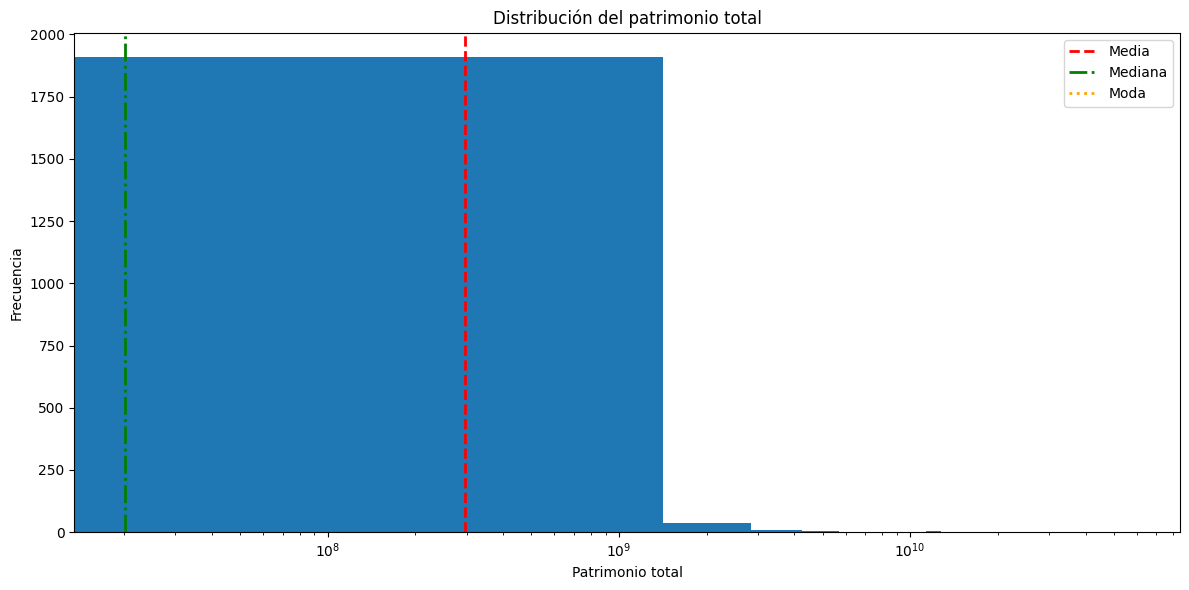

In [ ]:
media = df_limpio['patrimonio_total'].mean()

mediana = df_limpio['patrimonio_total'].median()

moda = df_limpio['patrimonio_total'].mode()[0]

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    df_limpio['patrimonio_total'],
    bins=40
)

# media
ax.axvline(
    media,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Media'
)

# mediana
ax.axvline(
    mediana,
    color='green',
    linestyle='-.',
    linewidth=2,
    label='Mediana'
)

# moda
ax.axvline(
    moda,
    color='orange',
    linestyle=':',
    linewidth=2,
    label='Moda'
)

ax.set_title(
    'Distribución del patrimonio total'
)

ax.set_xlabel('Patrimonio total')
ax.set_ylabel('Frecuencia')

ax.legend()

plt.xscale('log')
plt.tight_layout()
plt.show()

#### 2. Tablas de Frecuencia y Proporciones para Variables Categóricas

Las tablas de frecuencia muestran cuántas veces aparece cada categoría y qué porcentaje representa sobre el total. Son fundamentales para entender la composición del dataset por jurisdicción, tipo de declaración y jerarquía.

In [ ]:
# ── 2.1 Tipo de DDJJ ────────────────────────────────────────────────────────
freq_tipo = df_limpio['tipoddjj'].value_counts()
prop_tipo = df_limpio['tipoddjj'].value_counts(normalize=True).mul(100).round(1)

tabla_tipo = pd.DataFrame({'Frecuencia': freq_tipo, 'Porcentaje (%)': prop_tipo})
print("=== Tipo de Declaración Jurada ===")
display(tabla_tipo)
print()

# ── 2.2 Autoridad Superior ──────────────────────────────────────────────────
freq_aut = df_limpio['autoridad_superior'].value_counts()
prop_aut = df_limpio['autoridad_superior'].value_counts(normalize=True).mul(100).round(1)

tabla_aut = pd.DataFrame({'Frecuencia': freq_aut, 'Porcentaje (%)': prop_aut})
print("=== Nivel de Autoridad Superior ===")
display(tabla_aut)
print()

# ── 2.3 Top 10 Jurisdicciones ────────────────────────────────────────────────
freq_jur = df_limpio['jurisdiccion'].value_counts().head(10)
prop_jur = df_limpio['jurisdiccion'].value_counts(normalize=True).mul(100).round(1).head(10)

tabla_jur = pd.DataFrame({'Frecuencia': freq_jur, 'Porcentaje (%)': prop_jur})
print("=== Top 10 Jurisdicciones con más declaraciones ===")
display(tabla_jur)

=== Tipo de Declaración Jurada ===


,Frecuencia,Porcentaje (%)
tipoddjj,,
ACTUALIZACIÓN,1119,56.8
INICIAL,420,21.3
FINAL,393,19.9
RATIFICACIÓN,25,1.3
RECTIFICACIÓN,14,0.7



=== Nivel de Autoridad Superior ===


,Frecuencia,Porcentaje (%)
autoridad_superior,,
SI,1111,56.4
NO,860,43.6



=== Top 10 Jurisdicciones con más declaraciones ===


,Frecuencia,Porcentaje (%)
jurisdiccion,,
MINISTERIO DE JUSTICIA Y SEGURIDAD,462,23.4
JEFATURA DE GABINETE DE MINISTROS,320,16.2
JEFATURA DE GOBIERNO,223,11.3
MINISTERIO DE SALUD,173,8.8
MINISTERIO DE DESARROLLO HUMANO Y HÁBITAT,167,8.5
MINISTERIO DE CULTURA,109,5.5
MINISTERIO DE EDUCACION,89,4.5
MINISTERIO DE DESARROLLO ECONOMICO Y PRODUCCION,84,4.3
MINISTERIO DE HACIENDA Y FINANZAS,79,4.0


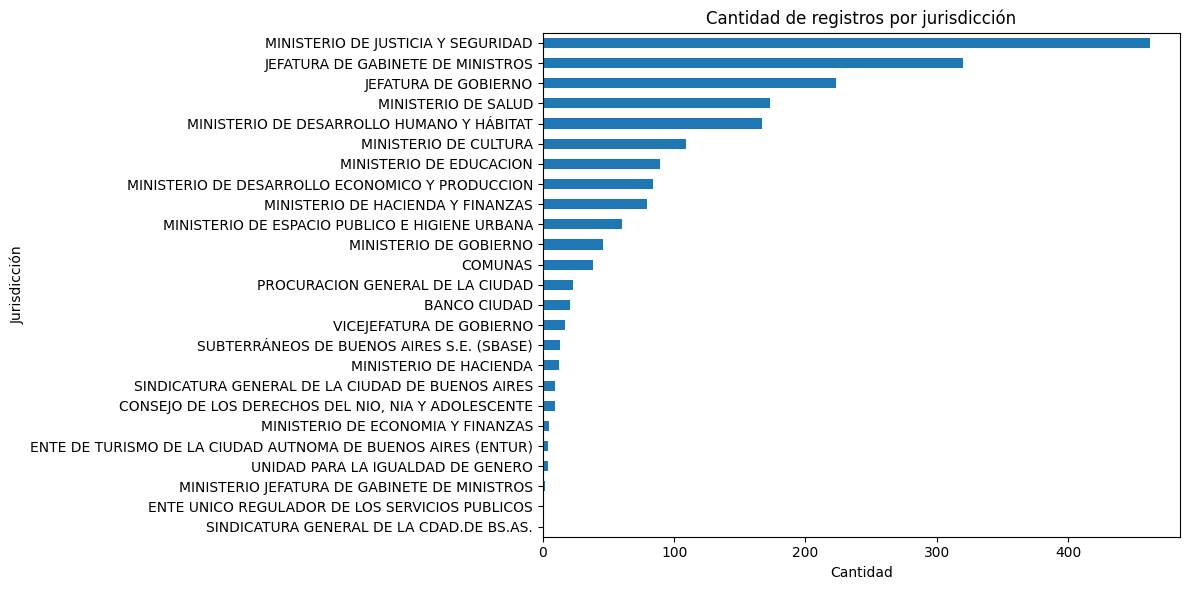

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

df_limpio['jurisdiccion'] \
    .value_counts() \
    .sort_values() \
    .plot(
        kind='barh',
        ax=ax
    )

ax.set_title(
    'Cantidad de registros por jurisdicción'
)

ax.set_xlabel('Cantidad')
ax.set_ylabel('Jurisdicción')

plt.tight_layout()
plt.show()

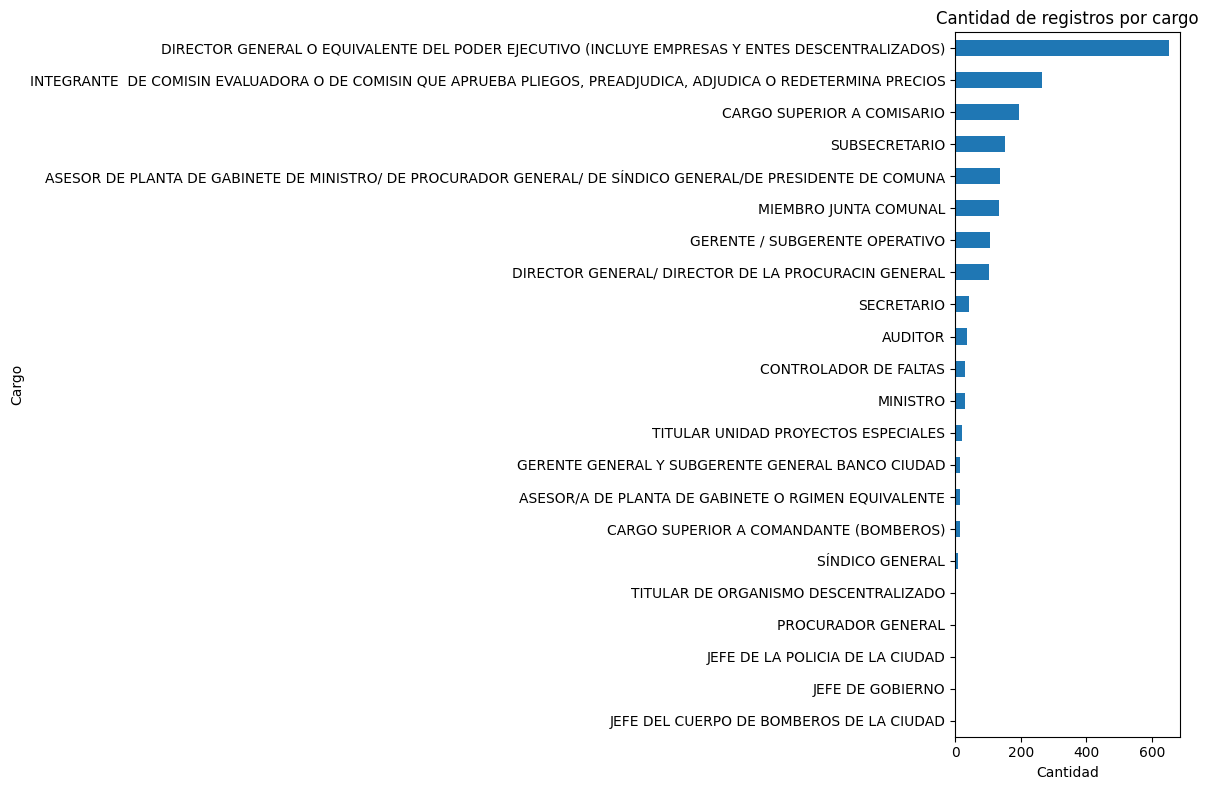

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

df_limpio['cargo'] \
    .value_counts() \
    .sort_values() \
    .plot(
        kind='barh',
        ax=ax
    )

ax.set_title(
    'Cantidad de registros por cargo'
)

ax.set_xlabel('Cantidad')
ax.set_ylabel('Cargo')

plt.tight_layout()
plt.show()

**Interpretación:**

- **Tipo de DDJJ:** Se espera que la mayoría sean de tipo **"INICIAL"** o **"ACTUALIZACIÓN"**, mientras que las de tipo **"FINAL"** (presentadas al dejar el cargo) son menos frecuentes. Esto refleja el ciclo de vida de la declaración patrimonial.
- **Autoridad Superior:** La gran mayoría de los registros corresponde a cargos **"NO"** autoridad superior, lo cual es esperable: hay pocos cargos jerárquicos altos y muchos mandos medios/técnicos. Este desbalance es importante a tener en cuenta en análisis futuros.
- **Jurisdicciones:** Las áreas con mayor cantidad de funcionarios (y por lo tanto más declaraciones) suelen ser las más grandes en personal, como Salud o Educación. El top 10 nos da una primera imagen de dónde se concentra la masa de declarantes.

#### 3. Identificación y Análisis de Valores Atípicos (Outliers)

Un **outlier** es un valor que se aleja significativamente del resto de los datos. En este dataset, los outliers patrimoniales representan a funcionarios con riquezas **muy por encima** del promedio.

Usamos el método del **IQR (Rango Intercuartílico)**:
- Se calcula: `Límite superior = Q3 + 1.5 × IQR`
- Todo valor por encima de ese límite se considera outlier.

In [ ]:
# Análisis de outliers en 'patrimonio_total' usando IQR
col = 'patrimonio_total'

Q1 = df_limpio[col].quantile(0.25)
Q3 = df_limpio[col].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR  # En datos de riqueza, el límite inferior suele ser < 0

# Identificamos los outliers
outliers = df_limpio[df_limpio[col] > limite_superior]
no_outliers = df_limpio[df_limpio[col] <= limite_superior]

print("=== Detección de Outliers en 'patrimonio_total' (método IQR) ===\n")
print(f"  Q1 (percentil 25):    $ {Q1:,.0f}")
print(f"  Q3 (percentil 75):    $ {Q3:,.0f}")
print(f"  IQR (Q3 - Q1):        $ {IQR:,.0f}")
print(f"  Límite superior:      $ {limite_superior:,.0f}")
print()
print(f"  Total de registros:       {len(df_limpio)}")
print(f"  Registros con outlier:    {len(outliers)} ({len(outliers)/len(df_limpio)*100:.1f}%)")
print(f"  Registros sin outlier:    {len(no_outliers)} ({len(no_outliers)/len(df_limpio)*100:.1f}%)")

=== Detección de Outliers en 'patrimonio_total' (método IQR) ===

  Q1 (percentil 25):    $ 2,629,485
  Q3 (percentil 75):    $ 121,066,362
  IQR (Q3 - Q1):        $ 118,436,876
  Límite superior:      $ 298,721,676

  Total de registros:       1971
  Registros con outlier:    263 (13.3%)
  Registros sin outlier:    1708 (86.7%)


In [ ]:
# Comparamos las estadísticas con y sin outliers
print("=== Impacto de los outliers sobre 'patrimonio_total' ===\n")
print(f"{'Métrica':<20} {'Con outliers':>18} {'Sin outliers':>18}")
print("-" * 58)
print(f"{'Media':.<20} $ {df_limpio[col].mean():>15,.0f} $ {no_outliers[col].mean():>15,.0f}")
print(f"{'Mediana':.<20} $ {df_limpio[col].median():>15,.0f} $ {no_outliers[col].median():>15,.0f}")
print(f"{'Desv. Estándar':.<20} $ {df_limpio[col].std():>15,.0f} $ {no_outliers[col].std():>15,.0f}")
print(f"{'Máximo':.<20} $ {df_limpio[col].max():>15,.0f} $ {no_outliers[col].max():>15,.0f}")
print()
print("--- Top 5 patrimonios más altos (outliers) ---")
top5 = outliers[['jurisdiccion', 'cargo', 'autoridad_superior', 'patrimonio_total']].nlargest(5, 'patrimonio_total')
display(top5.reset_index(drop=True))

=== Impacto de los outliers sobre 'patrimonio_total' ===

Métrica                    Con outliers       Sin outliers
----------------------------------------------------------
Media............... $     296,731,064 $      45,368,085
Mediana............. $      20,078,000 $      12,384,350
Desv. Estándar...... $   2,248,680,994 $      66,565,505
Máximo.............. $  56,733,504,573 $     293,423,393

--- Top 5 patrimonios más altos (outliers) ---


,jurisdiccion,cargo,autoridad_superior,patrimonio_total
0,MINISTERIO DE DESARROLLO ECONOMICO Y PRODUCCION,SUBSECRETARIO,SI,5.673350e+10
1,MINISTERIO DE SALUD,DIRECTOR GENERAL O EQUIVALENTE DEL PODER EJECU...,SI,5.171706e+10
2,MINISTERIO DE SALUD,DIRECTOR GENERAL O EQUIVALENTE DEL PODER EJECU...,SI,5.171706e+10
3,BANCO CIUDAD,GERENTE GENERAL Y SUBGERENTE GENERAL BANCO CIUDAD,SI,1.930756e+10
4,JEFATURA DE GOBIERNO,SECRETARIO,SI,1.175233e+10


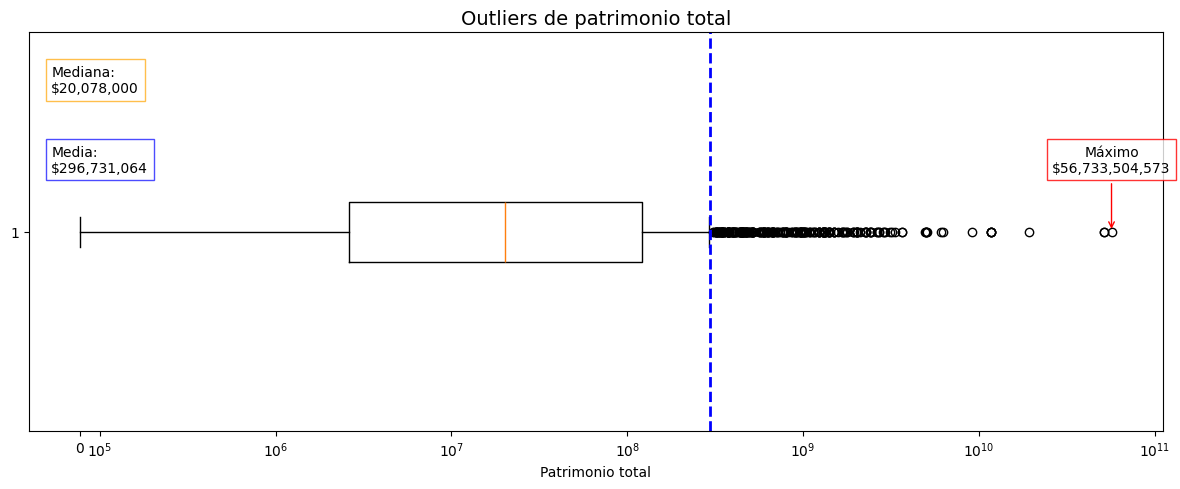

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

# =========================
# BOXPLOT
# =========================

ax.boxplot(
    df_limpio['patrimonio_total'],
    vert=False
)

# =========================
# ESCALA
# =========================

ax.set_xscale(
    'symlog',
    linthresh=10**6
)

# =========================
# ESTADISTICAS
# =========================

datos = df_limpio['patrimonio_total']

media = datos.mean()
mediana = datos.median()
maximo = datos.max()

ax.axvline(
    media,
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Media: ${media:,.0f}'
)

ax.text(
    0.02,
    0.65,
    f'Media:\n${media:,.0f}',
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        alpha=0.7,
        edgecolor='blue'
    )
)

ax.text(
    0.02,
    0.85,
    f'Mediana:\n${mediana:,.0f}',
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(
        facecolor='white',
        alpha=0.7,
        edgecolor='orange'
    )
)

ax.annotate(
    f'Máximo\n${maximo:,.0f}',
    xy=(maximo, 1),
    xytext=(maximo, 1.15),
    textcoords='data',
    ha='center',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'),
    arrowprops=dict(arrowstyle='->', color='red')
)

# =========================
# TITULOS
# =========================

ax.set_title(
    'Outliers de patrimonio total',
    fontsize=14
)

ax.set_xlabel(
    'Patrimonio total'
)

plt.tight_layout()
plt.show()

**Interpretación de Outliers:**

- El método IQR identifica un subconjunto pequeño de funcionarios con patrimonios muy por encima de la mayoría. Aunque representan un porcentaje pequeño del total de declarantes, **distorsionan significativamente la media**.
- La comparación entre "con outliers" y "sin outliers" muestra cuánto baja la media al excluirlos, mientras que la **mediana apenas varía**. Esto confirma que la mediana es una medida más representativa del "funcionario típico" en este dataset.
- Los outliers no son errores de carga: representan funcionarios reales con patrimonios declarados muy altos. Su presencia es un hallazgo de negocio relevante, vinculado directamente con la **pregunta analítica nº 2** de la Entrega 1 (brecha patrimonial entre autoridades superiores y cargos subordinados).
- En fases posteriores del análisis, se deberá decidir si incluir o excluir estos valores según el objetivo: para modelado predictivo suelen distorsionar; para análisis de desigualdad son precisamente lo que se quiere estudiar.

### C. Análisis de relaciones entre variables

Analizar las relaciones entre variables nos permite identificar cómo ciertas características institucionales, como la jurisdicción, el cargo o la autoridad superior, se asocian con las variaciones en el patrimonio total declarado.

* Para el estudio de los gráficos, se optó por una **escala logarítmica simétrica**: desde 0 a un millón, la escala del `eje y` crece de manera lineal. Superado ese valor, la escala crece de forma logarítmica (cada incremento en la escala multiplica por diez al anterior).

- Comenzamos observando los *outliers* por `jurisdicción`, separando y agrupando las DDJJ de aquellos funcionarios categorizados como autoridad superior y aquellos que no lo son. Para esto utilizaremos dos grupos de diagramas distintos: *boxplot*, para observar más detenidamente las medidas de dispersión y los *outliers*; y *violin plot*, para ver la proporción de los valores atípicos respecto de la mayoría de los datos de la muestra de cada jurisdicción.

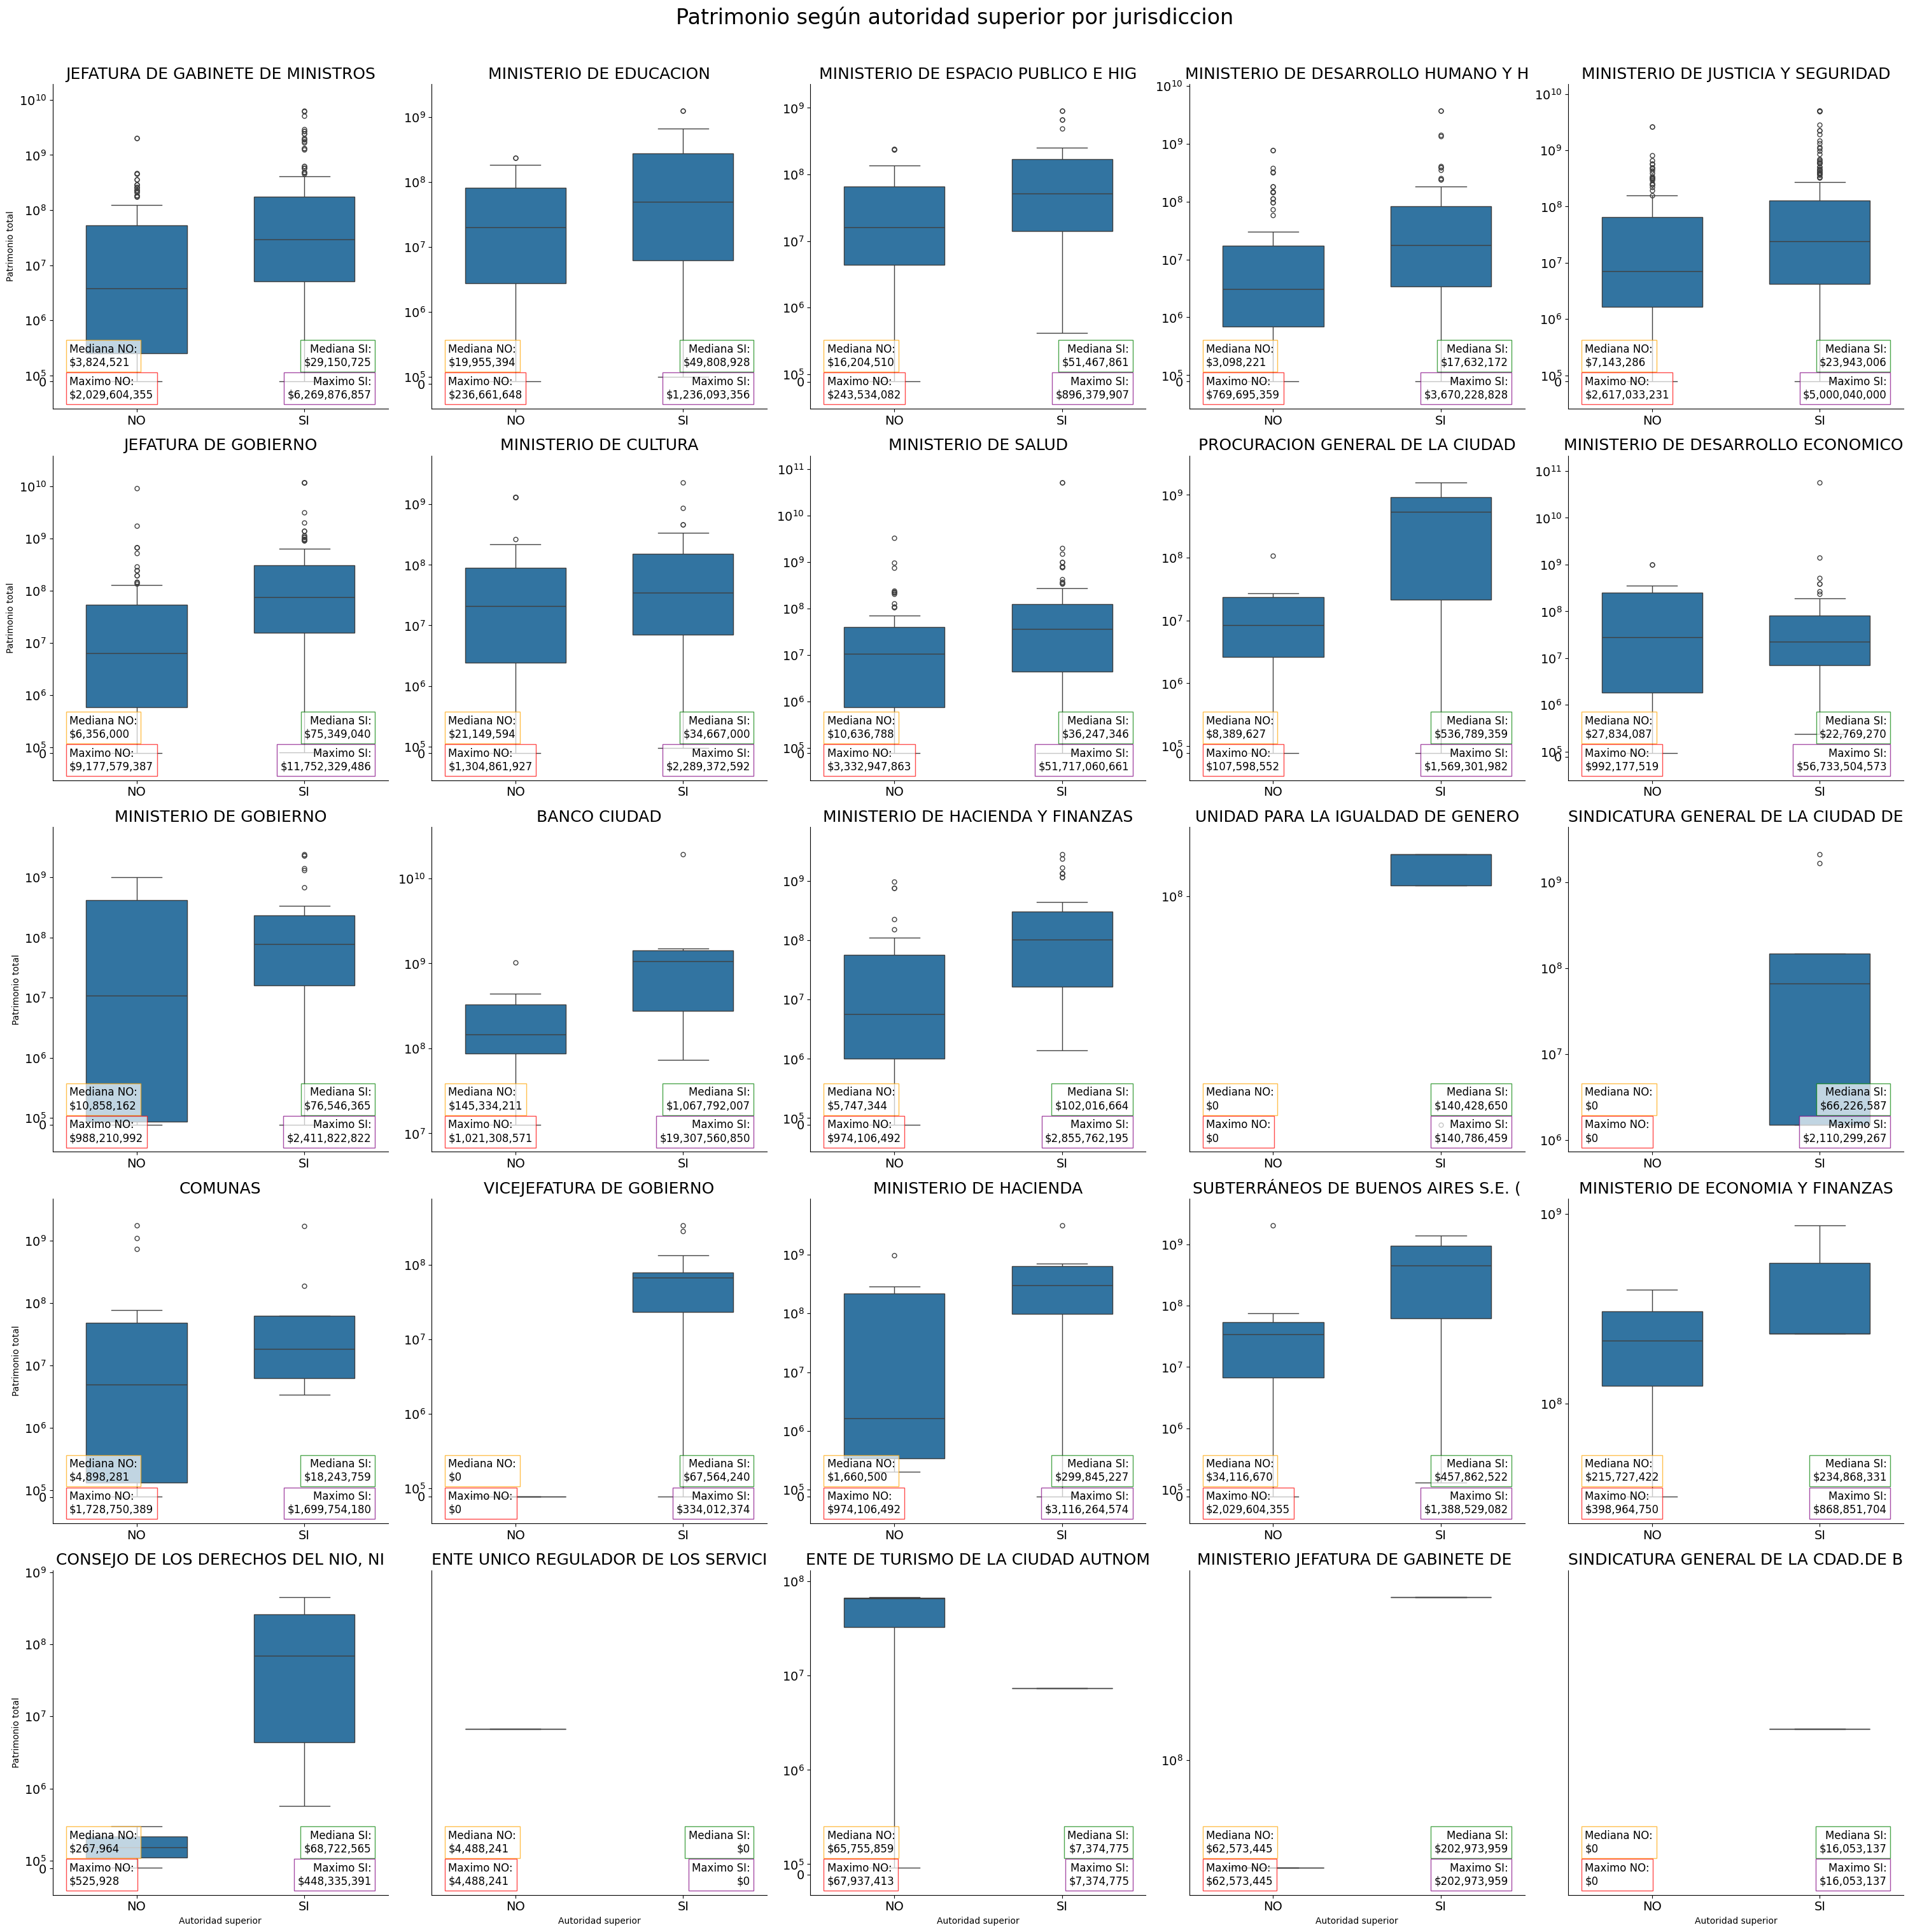

In [ ]:
g = sns.catplot(
    data=df_limpio,
    x='autoridad_superior',
    y='patrimonio_total',
    col='jurisdiccion',
    kind='box',
    col_wrap=5,
    height=6,
    sharey=False,
    width=0.6,
    showfliers=True
)

# =========================
# ESCALA SYMLOG
# =========================

for ax in g.axes.flat:

    ax.set_yscale(
        'symlog',
        linthresh=10**6
    )

    ax.tick_params(axis='x', labelbottom=True)

    ax.tick_params(axis='both', labelsize=14)

    ax.margins(y=0.1)

    ax.set_title(
        ax.get_title().replace('jurisdiccion = ', '')[:35],
        fontsize=18
    )

# =========================
# TITULOS
# =========================

g.set_axis_labels(
    'Autoridad superior',
    'Patrimonio total'
)

g.fig.subplots_adjust(
    top=0.92,
    hspace=0.8,
    wspace=0.5
)

g.fig.suptitle(
    'Patrimonio según autoridad superior por jurisdiccion',
    fontsize=24,
    y=1.01
)

for ax, jurisdiccion in zip(
    g.axes.flat,
    df_limpio['jurisdiccion'].unique()
):

    datos_juri = df_limpio[
        df_limpio['jurisdiccion'] == jurisdiccion
    ]

    # =========================
    # GRUPOS
    # =========================

    datos_no = datos_juri[
        datos_juri['autoridad_superior'] == 'NO'
    ]['patrimonio_total']

    datos_si = datos_juri[
        datos_juri['autoridad_superior'] == 'SI'
    ]['patrimonio_total']

    # =========================
    # MEDIANAS
    # =========================

    mediana_no = datos_no.median()
    mediana_si = datos_si.median()

    mediana_no = 0 if (pd.isna(mediana_no) or mediana_no == 'nan') else mediana_no
    mediana_si = 0 if (pd.isna(mediana_si) or mediana_si == 'nan') else mediana_si

    # =========================
    # MAXIMOS
    # =========================

    max_no = datos_no.max()
    max_si = datos_si.max()

    max_no = 0 if (pd.isna(max_no) or max_no == 'nan') else max_no
    max_si = 0 if (pd.isna(max_si) or max_si == 'nan') else max_si

    # =========================
    # NO MEDIANA
    # =========================

    ax.text(
        0.05,
        0.2,
        f'Mediana NO:\n${mediana_no:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='orange'
        )
    )

    # =========================
    # NO MAXIMO
    # =========================

    ax.text(
        0.05,
        0.1,
        f'Maximo NO:\n${max_no:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='red'
        )
    )

    # =========================
    # SI MEDIANA
    # =========================

    ax.text(
        0.95,
        0.2,
        f'Mediana SI:\n${mediana_si:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='green'
        )
    )

    # =========================
    # SI MAXIMO
    # =========================

    ax.text(
        0.95,
        0.1,
        f'Maximo SI:\n${max_si:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='purple'
        )
    )


plt.tight_layout()
plt.show()

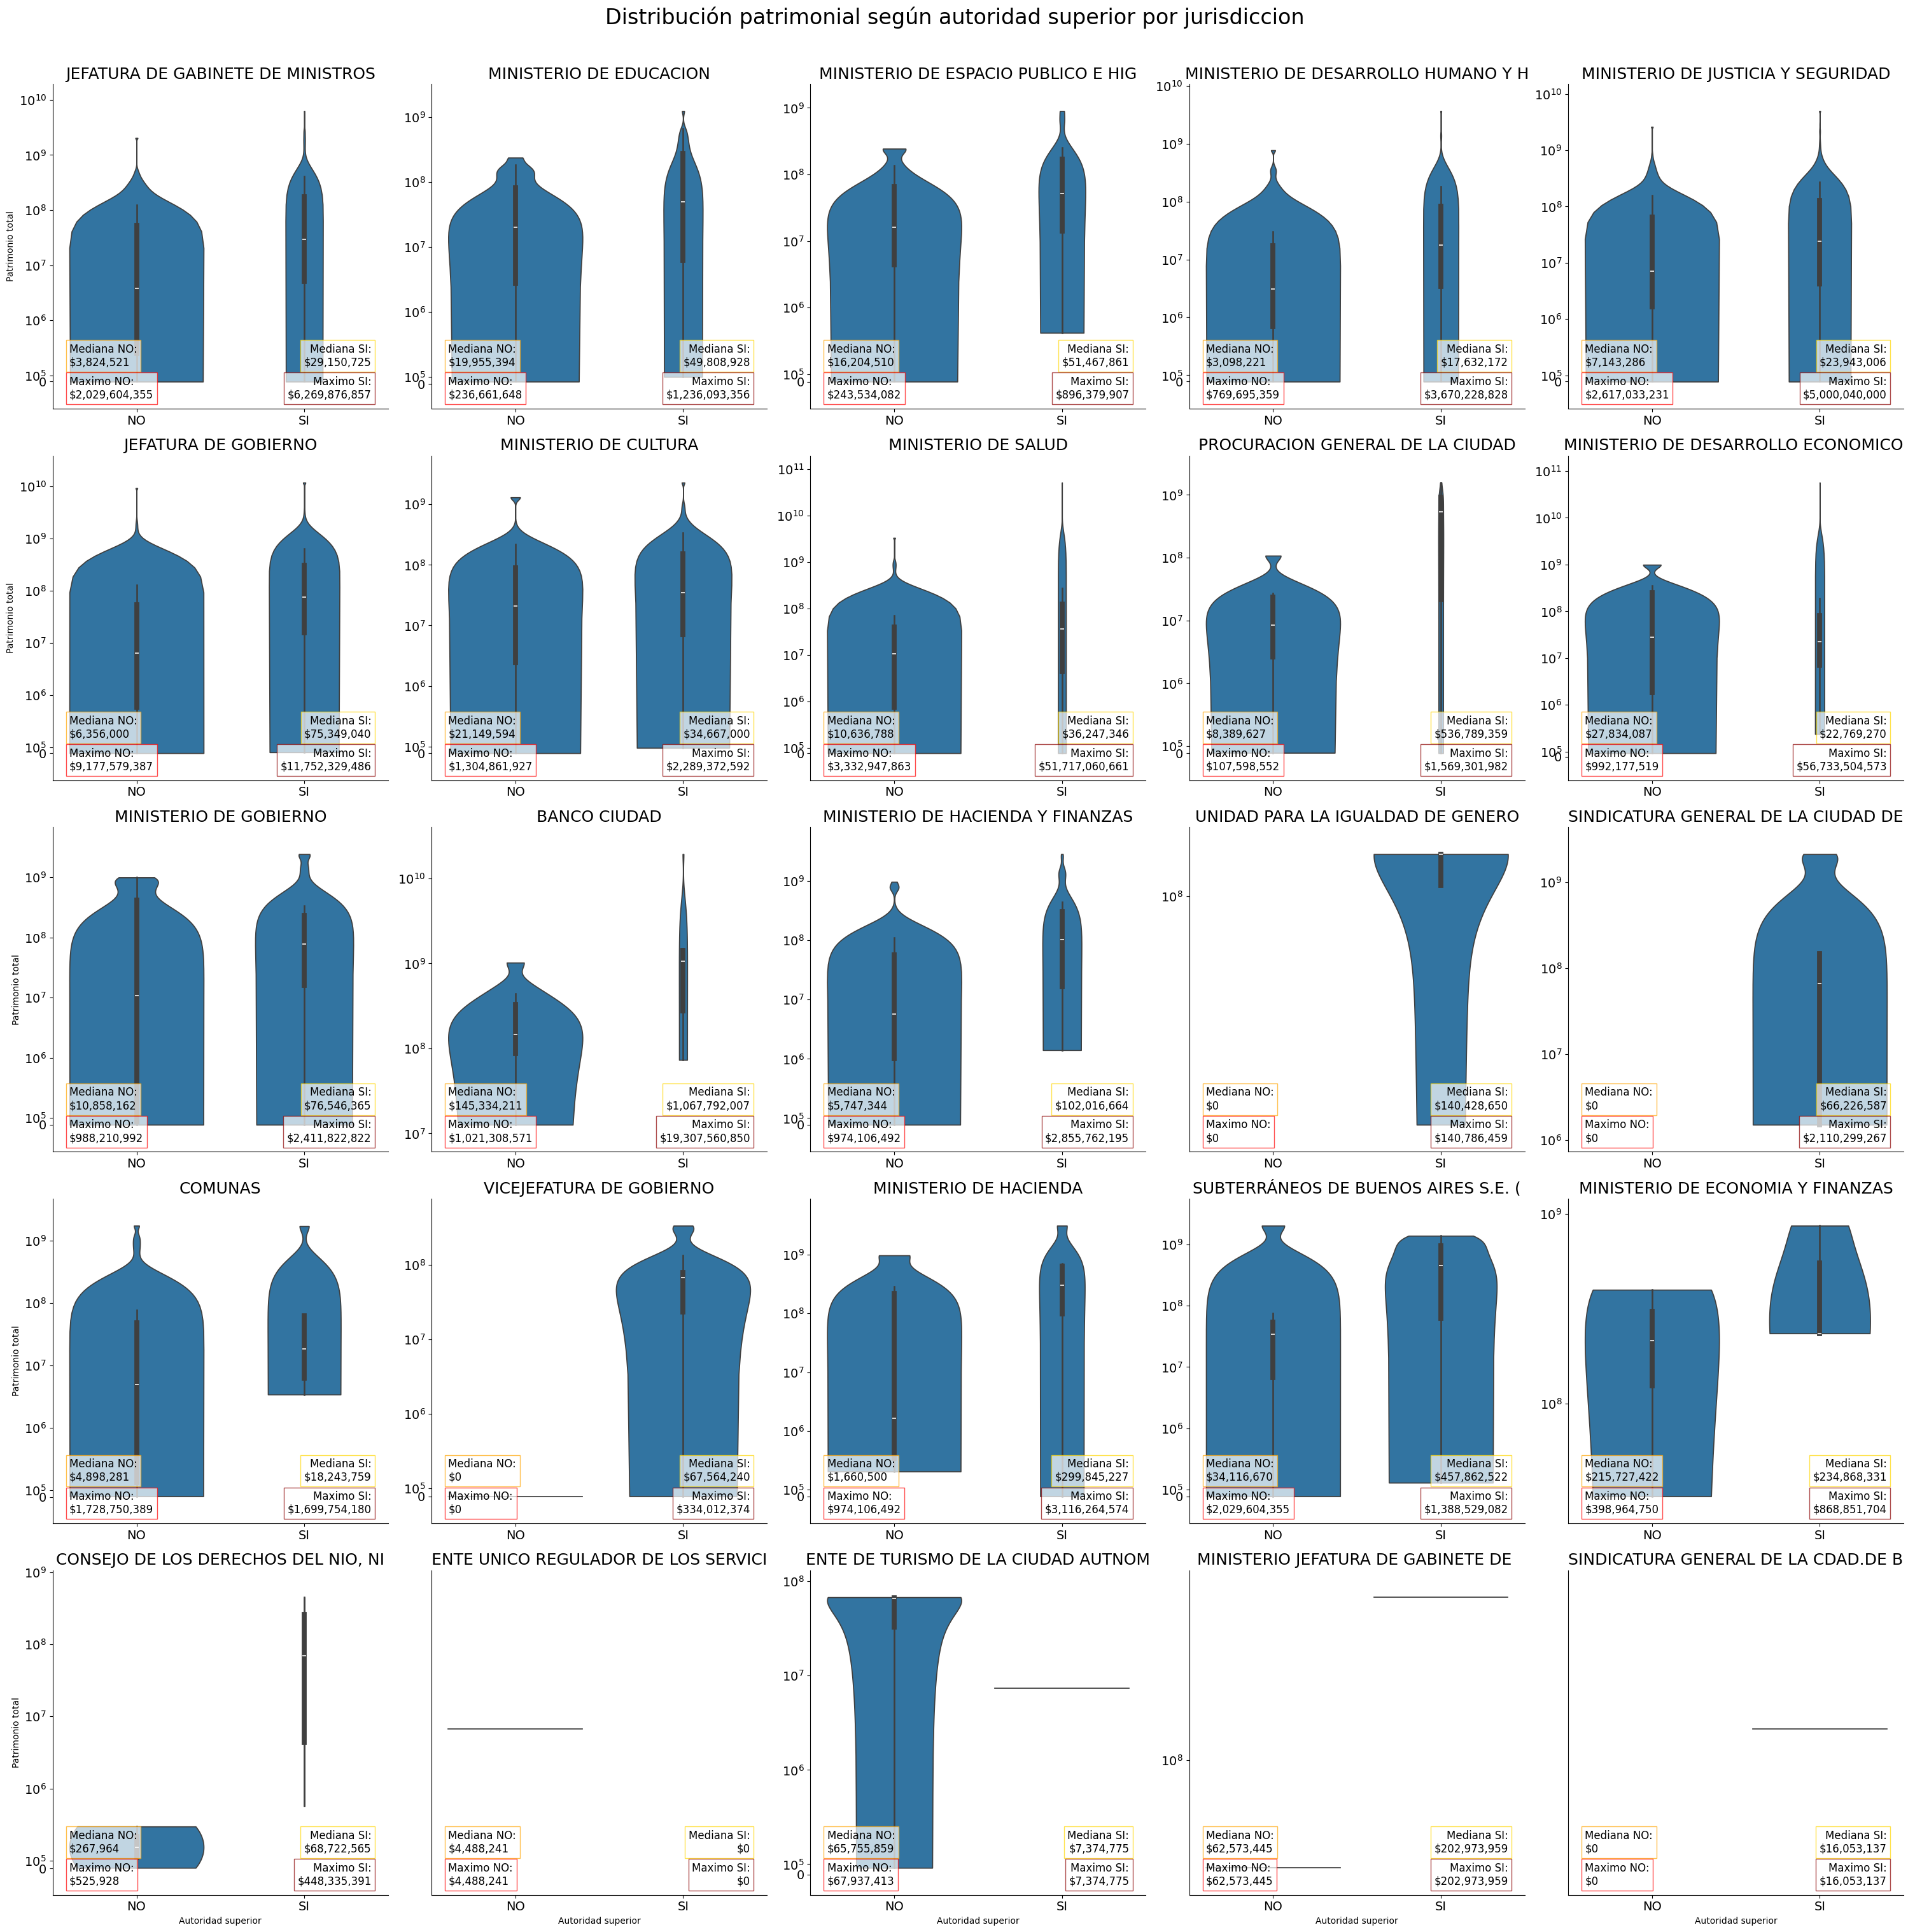

In [ ]:
g = sns.catplot(
    data=df_limpio,
    x='autoridad_superior',
    y='patrimonio_total',
    col='jurisdiccion',
    kind='violin',
    col_wrap=5,
    height=6,
    sharey=False,
    cut=0,
    inner='box'
)

# =========================
# ESCALA SYMLOG
# =========================

for ax in g.axes.flat:

    ax.set_yscale(
        'symlog',
        linthresh=10**6
    )

    ax.tick_params(axis='x', labelbottom=True)

    ax.tick_params(axis='both', labelsize=14)

    ax.margins(y=0.1)

    ax.set_title(
        ax.get_title().replace('jurisdiccion = ', '')[:35],
        fontsize=18
    )

# =========================
# TITULOS
# =========================

g.set_axis_labels(
    'Autoridad superior',
    'Patrimonio total'
)

g.fig.subplots_adjust(
    top=0.92,
    hspace=0.8,
    wspace=0.5
)

g.fig.suptitle(
    'Distribución patrimonial según autoridad superior por jurisdiccion',
    fontsize=24,
    y=1.01
)

for ax, jurisdiccion in zip(
    g.axes.flat,
    df_limpio['jurisdiccion'].unique()
):

    datos_juri = df_limpio[
        df_limpio['jurisdiccion'] == jurisdiccion
    ]

    # =========================
    # GRUPOS
    # =========================

    datos_no = datos_juri[
        datos_juri['autoridad_superior'] == 'NO'
    ]['patrimonio_total']

    datos_si = datos_juri[
        datos_juri['autoridad_superior'] == 'SI'
    ]['patrimonio_total']

    # =========================
    # MEDIANAS
    # =========================

    mediana_no = datos_no.median()
    mediana_si = datos_si.median()

    mediana_no = 0 if (pd.isna(mediana_no) or mediana_no == 'nan') else mediana_no
    mediana_si = 0 if (pd.isna(mediana_si) or mediana_si == 'nan') else mediana_si

    # =========================
    # MAXIMOS
    # =========================

    max_no = datos_no.max()
    max_si = datos_si.max()

    max_no = 0 if (pd.isna(max_no) or max_no == 'nan') else max_no
    max_si = 0 if (pd.isna(max_si) or max_si == 'nan') else max_si

    # =========================
    # NO MEDIANA
    # =========================

    ax.text(
        0.05,
        0.2,
        f'Mediana NO:\n${mediana_no:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='orange'
        )
    )

    # =========================
    # NO MAXIMO
    # =========================

    ax.text(
        0.05,
        0.1,
        f'Maximo NO:\n${max_no:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='red'
        )
    )

    # =========================
    # SI MEDIANA
    # =========================

    ax.text(
        0.95,
        0.2,
        f'Mediana SI:\n${mediana_si:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='gold'
        )
    )

    # =========================
    # SI MAXIMO
    # =========================

    ax.text(
        0.95,
        0.1,
        f'Maximo SI:\n${max_si:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='darkred'
        )
    )

plt.tight_layout()
plt.show()

Al estudiar ambos conjuntos de gráficos, podemos extraer las siguientes conclusiones:

1. En casi todas las jurisdicciones, el patrimonio presenta una fuerte asimetría positiva (hacia la derecha/arriba).

2. Existe una minoría de funcionarios con patrimonios extremadamente elevados (*outliers*). La mayoría de los valores se concentra en rangos bajos o medios.

3. En la mayoría de los casos, las autoridades superiores muestran medianas y outliers más altos. Algunas jurisdicciones también muestran diferencias muy marcadas entre los funcionarios que son autoridad superior y los que no.

4. En prácticamente todos los paneles, se observan valores atípicos muy elevados, tanto entre las autoridades superiores como en las que no lo son.

5. Algunas jurisdicciones dominan visualmente el rango de valores: presentan máximos mucho más altos que el resto.

6. También cambia la **variabilidad interna** entre los funcionarios que son autoridades superiores y los que no lo son. Los grupos de autoridad superior presentan, en varios casos, mayor desigualdad interna.

- Ahora hacemos lo mismo, pero para los cargos, separando y agrupando a aquellos funcionarios que son autoridades superiores de los que no lo son y midiendo el patrimonio total de ambos grupos. De nuevo, nos valemos de dos conjuntos gráficos: boxplots y violin-plots.

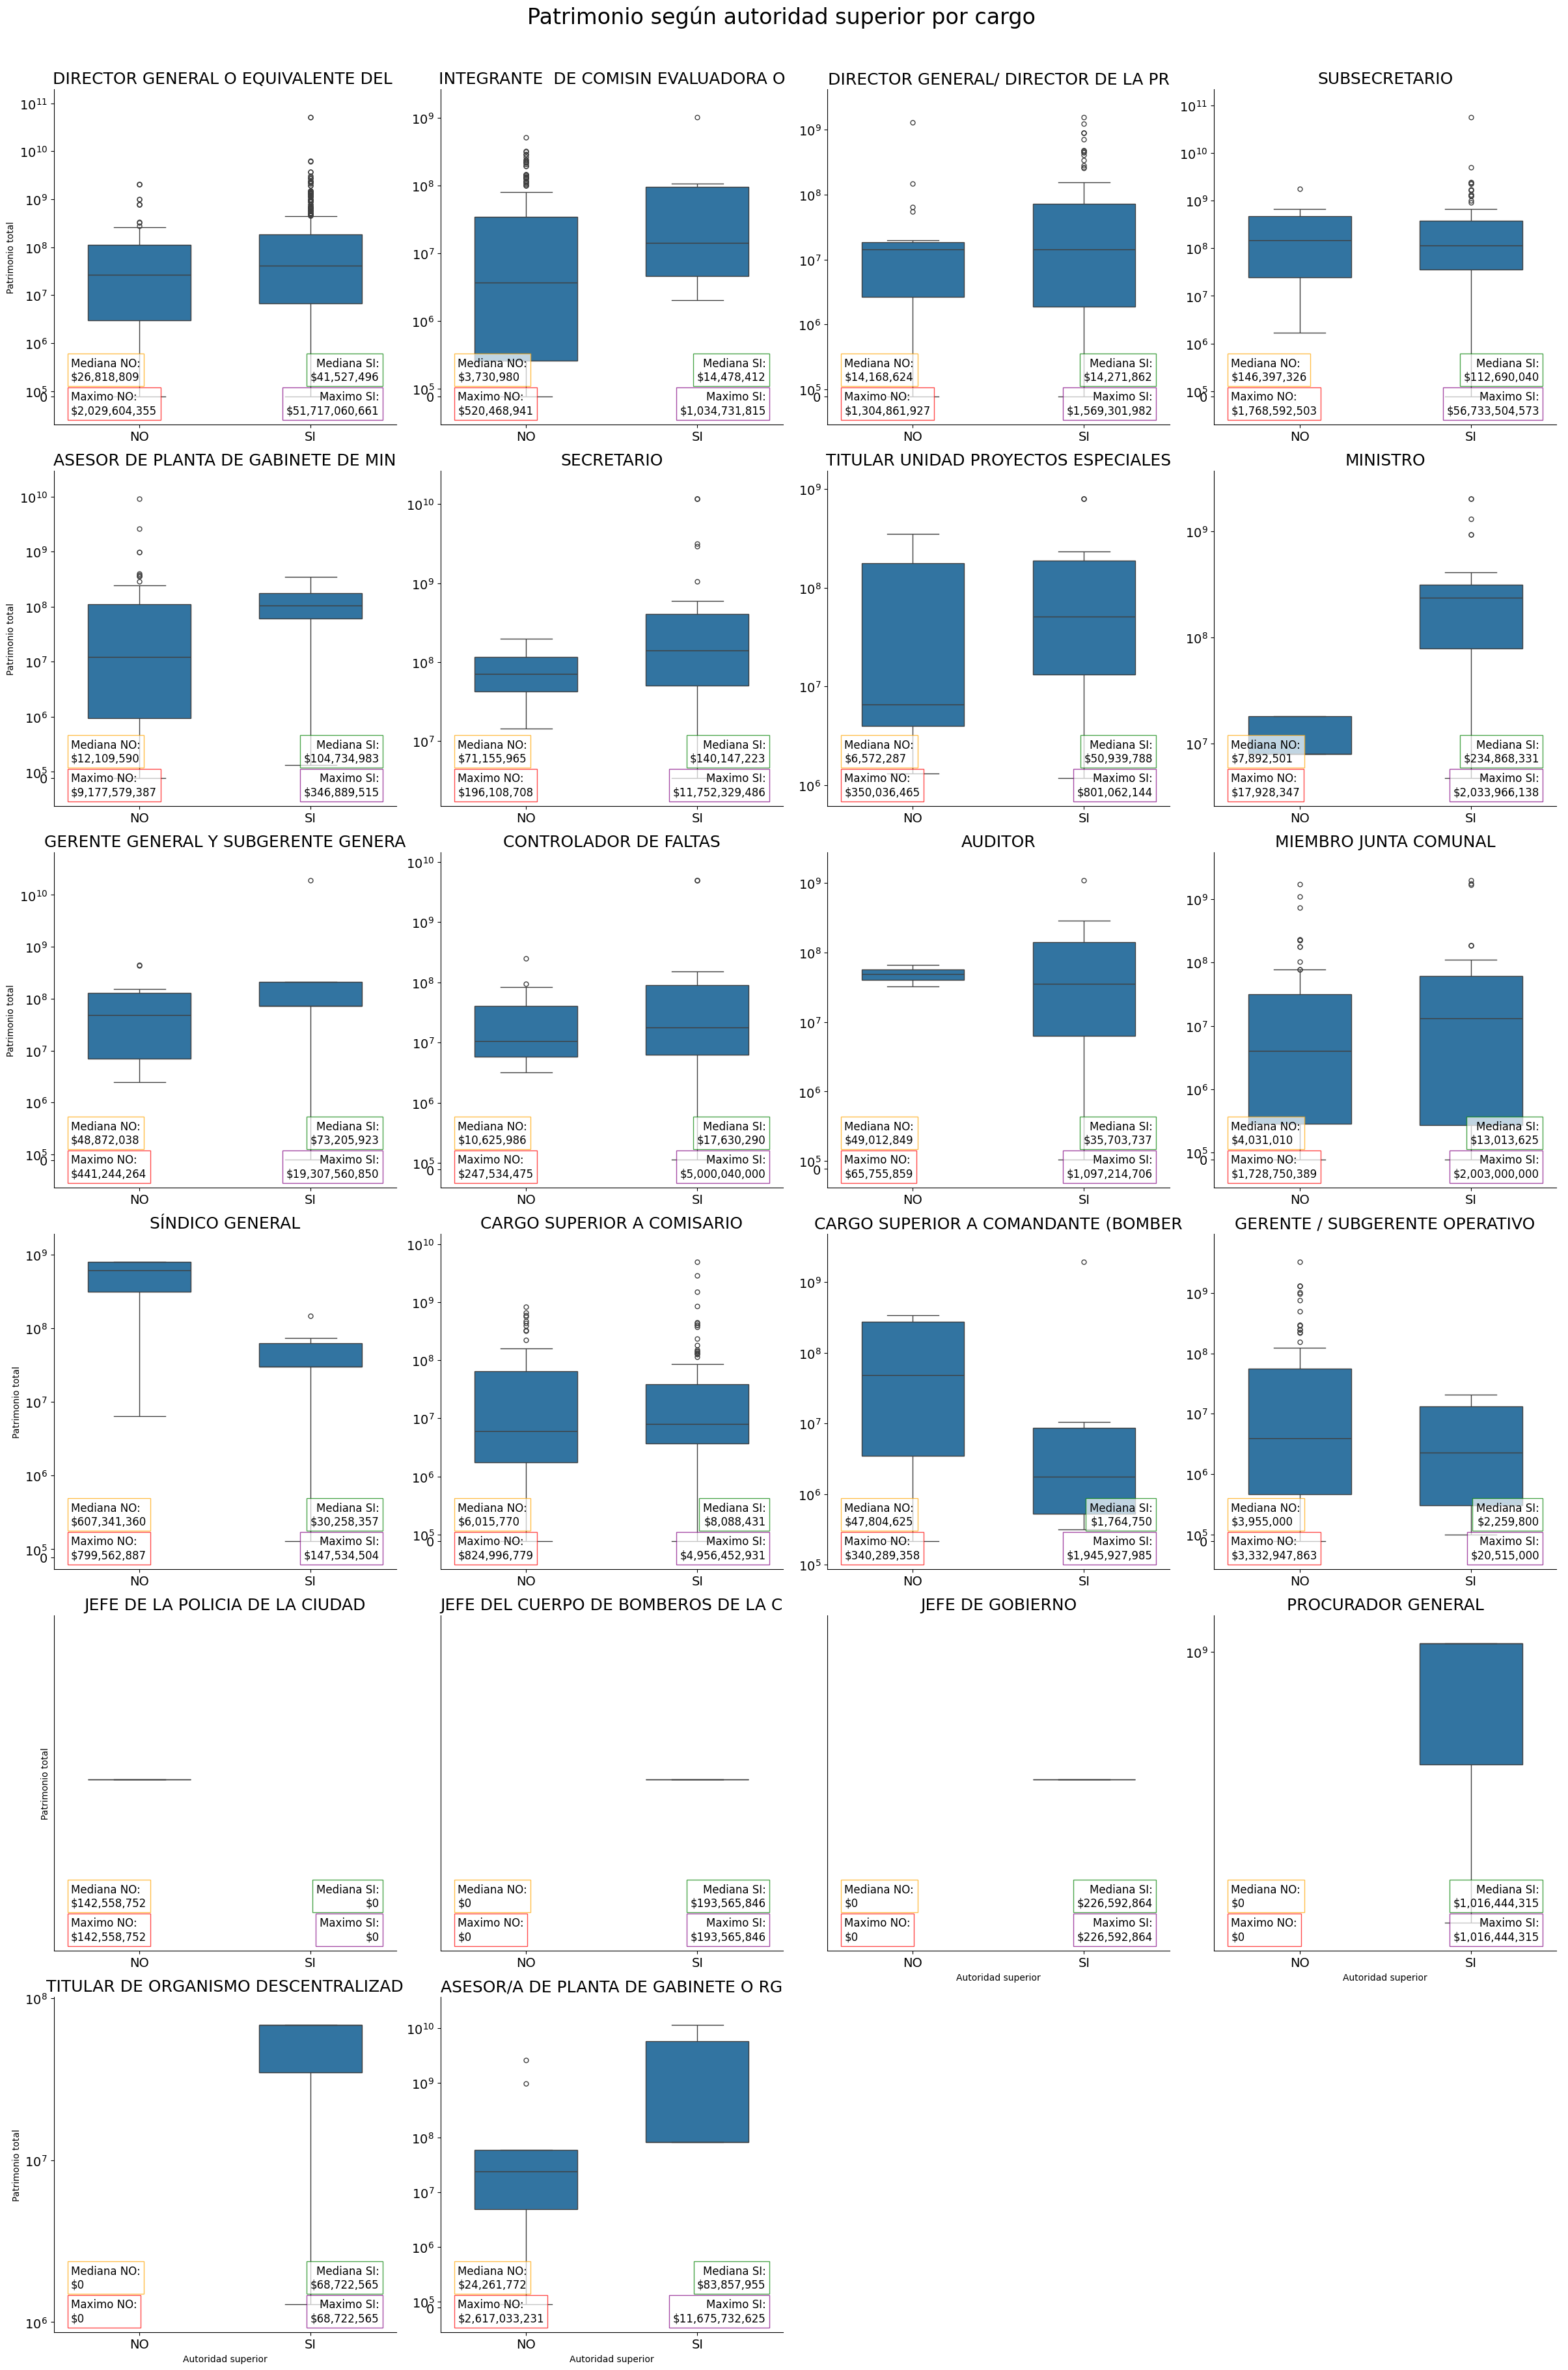

In [ ]:
g = sns.catplot(
    data=df_limpio,
    x='autoridad_superior',
    y='patrimonio_total',
    col='cargo',
    kind='box',
    col_wrap=4,
    height=6,
    sharey=False,
    width=0.6,
    showfliers=True
)

# =========================
# ESCALA SYMLOG
# =========================

for ax in g.axes.flat:

    ax.set_yscale(
        'symlog',
        linthresh=10**6
    )

    ax.tick_params(axis='x', labelbottom=True)

    ax.tick_params(axis='both', labelsize=14)

    ax.margins(y=0.1)

    ax.set_title(
        ax.get_title().replace('cargo = ', '')[:35],
        fontsize=18
    )

# =========================
# TITULOS
# =========================

g.set_axis_labels(
    'Autoridad superior',
    'Patrimonio total'
)

g.fig.subplots_adjust(
    top=0.92,
    hspace=0.8,
    wspace=0.5
)

g.fig.suptitle(
    'Patrimonio según autoridad superior por cargo',
    fontsize=24,
    y=1.01
)

for ax, cargo in zip(
    g.axes.flat,
    df_limpio['cargo'].unique()
):

    datos_cargo = df_limpio[
        df_limpio['cargo'] == cargo
    ]

    # =========================
    # GRUPOS
    # =========================

    datos_no = datos_cargo[
        datos_cargo['autoridad_superior'] == 'NO'
    ]['patrimonio_total']

    datos_si = datos_cargo[
        datos_cargo['autoridad_superior'] == 'SI'
    ]['patrimonio_total']

    # =========================
    # MEDIANAS
    # =========================

    mediana_no = datos_no.median()
    mediana_si = datos_si.median()

    mediana_no = 0 if pd.isna(mediana_no) else mediana_no
    mediana_si = 0 if pd.isna(mediana_si) else mediana_si

    # =========================
    # MAXIMOS
    # =========================

    max_no = datos_no.max()
    max_si = datos_si.max()

    max_no = 0 if pd.isna(max_no) else max_no
    max_si = 0 if pd.isna(max_si) else max_si

    # =========================
    # NO MEDIANA
    # =========================

    ax.text(
        0.05,
        0.2,
        f'Mediana NO:\n${mediana_no:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='orange'
        )
    )

    # =========================
    # NO MAXIMO
    # =========================

    ax.text(
        0.05,
        0.1,
        f'Maximo NO:\n${max_no:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='red'
        )
    )

    # =========================
    # SI MEDIANA
    # =========================

    ax.text(
        0.95,
        0.2,
        f'Mediana SI:\n${mediana_si:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='green'
        )
    )

    # =========================
    # SI MAXIMO
    # =========================

    ax.text(
        0.95,
        0.1,
        f'Maximo SI:\n${max_si:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='purple'
        )
    )

plt.tight_layout()
plt.show()

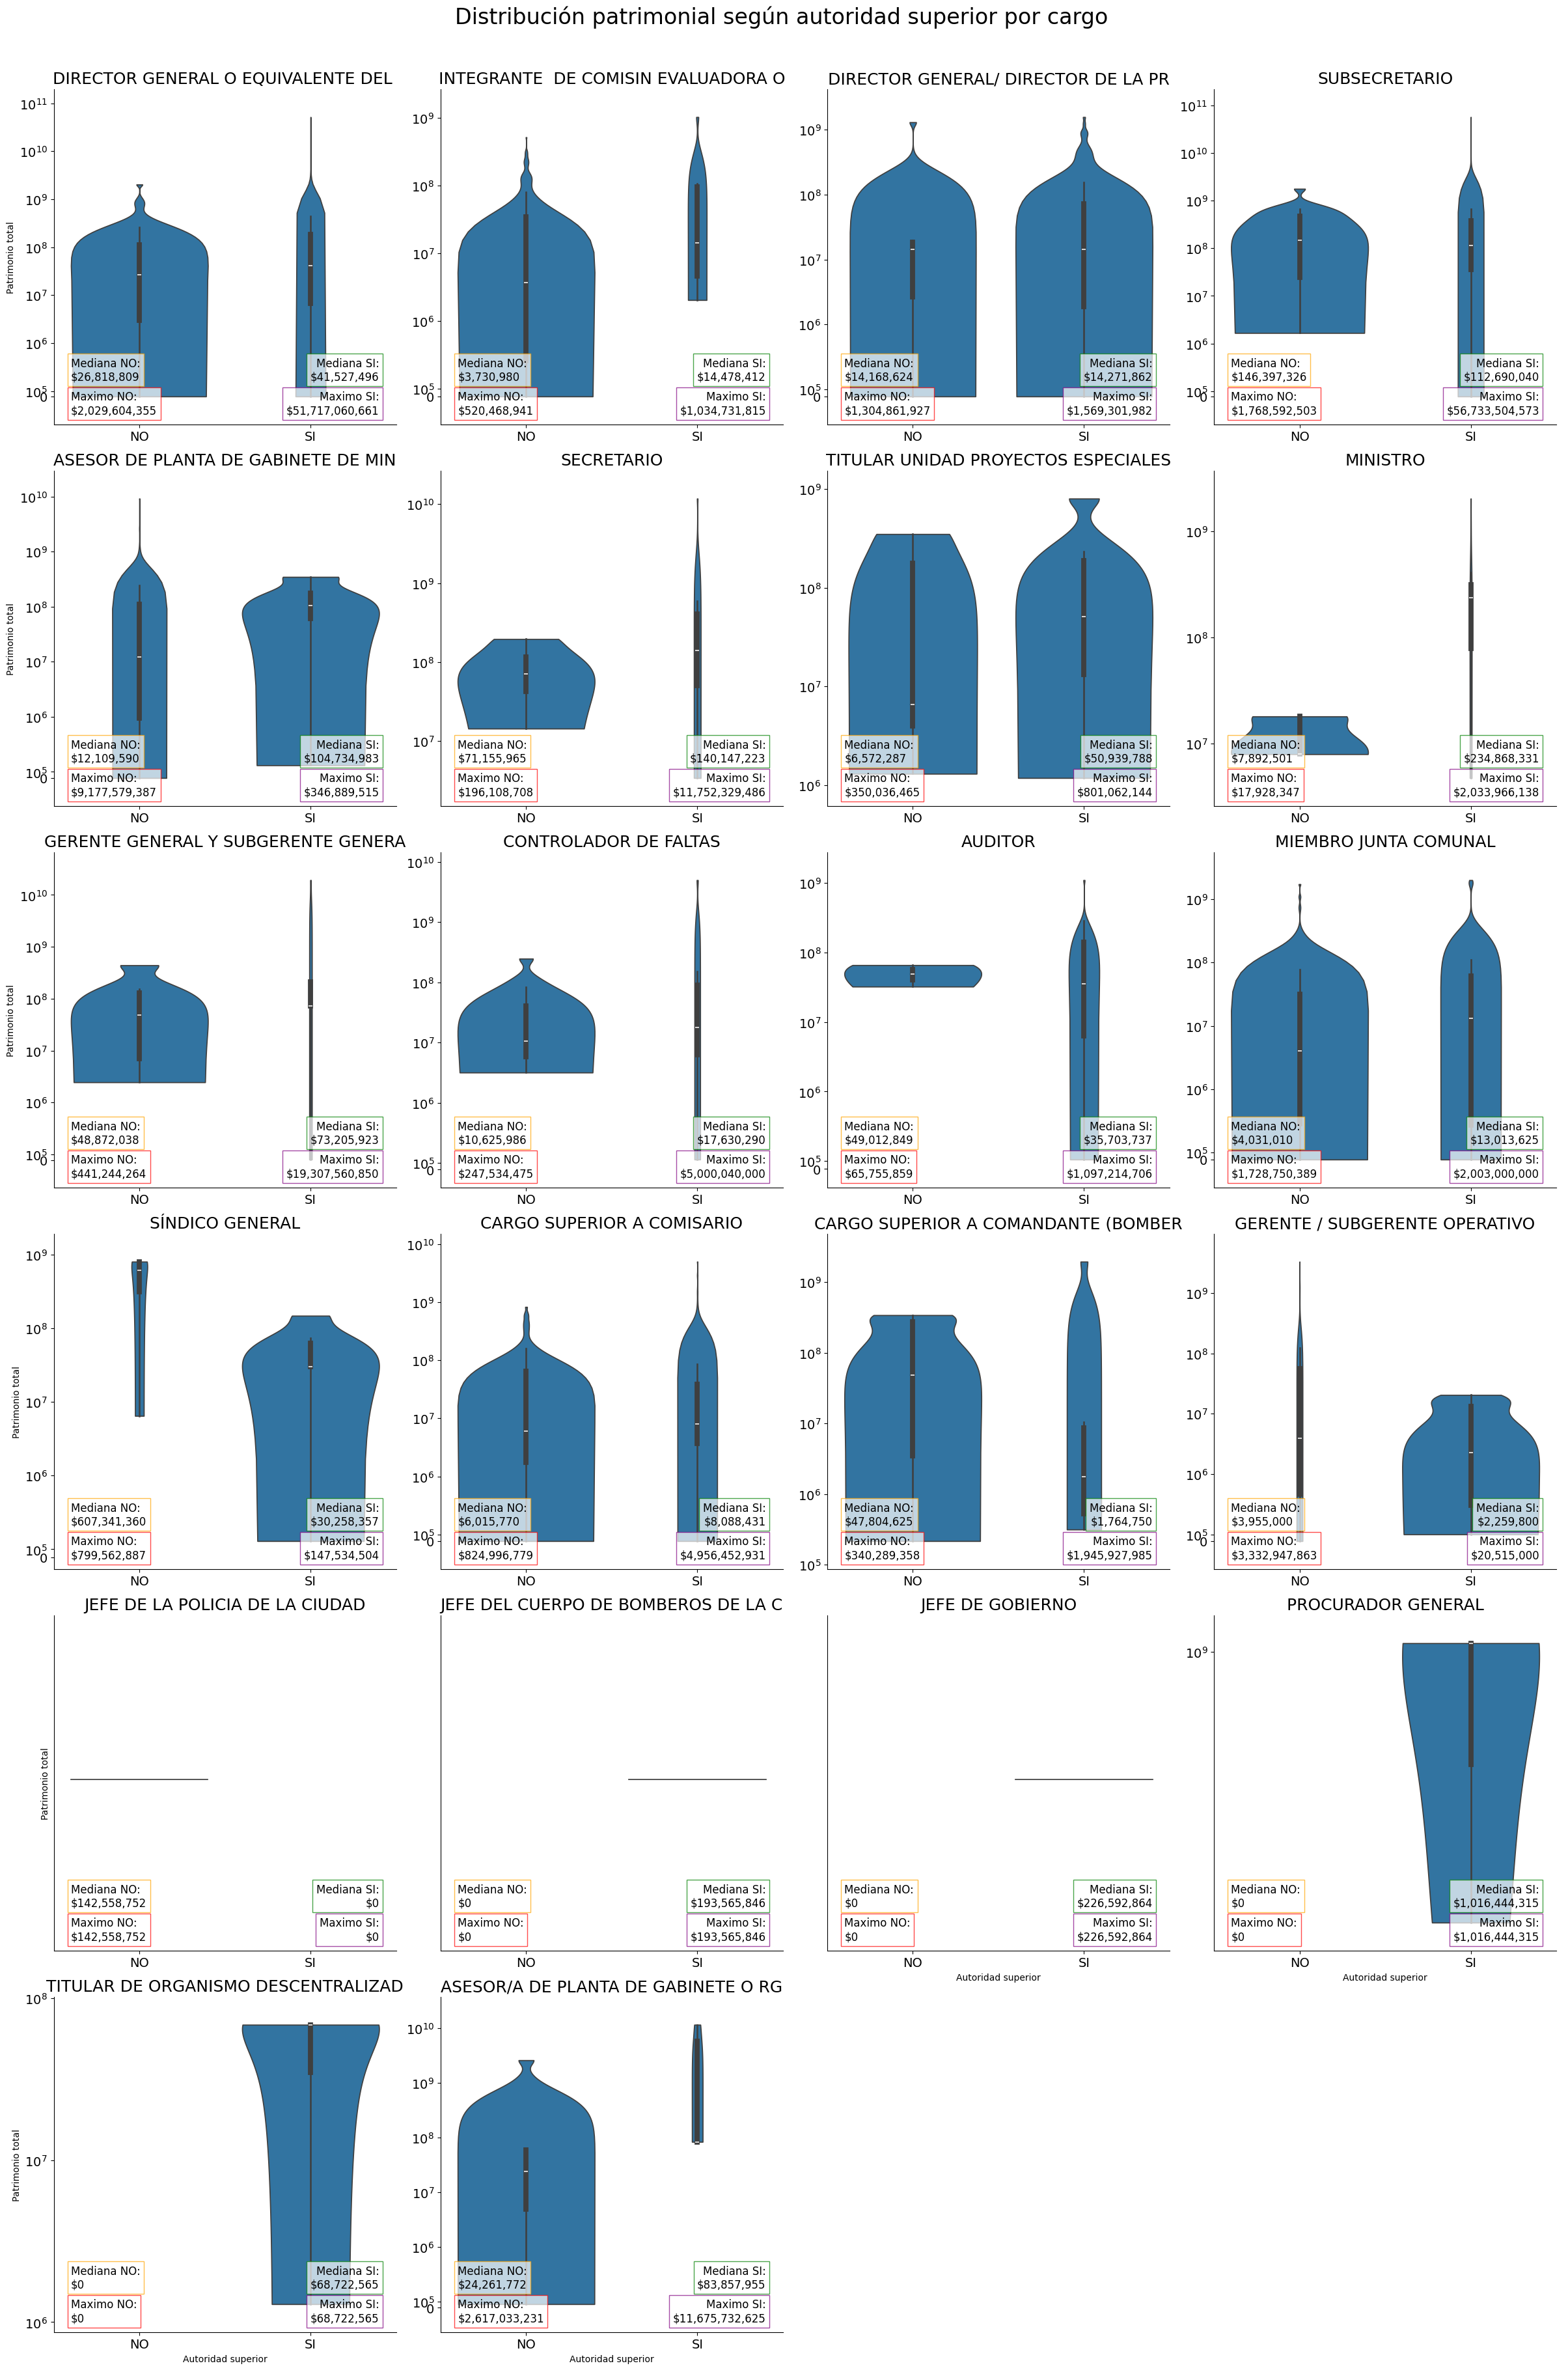

In [ ]:
g = sns.catplot(
    data=df_limpio,
    x='autoridad_superior',
    y='patrimonio_total',
    col='cargo',
    kind='violin',
    col_wrap=4,
    height=6,
    sharey=False,
    cut=0,
    inner='box'
)

# =========================
# ESCALA SYMLOG
# =========================

for ax in g.axes.flat:

    ax.set_yscale(
        'symlog',
        linthresh=10**6
    )

    ax.tick_params(axis='x', labelbottom=True)

    ax.tick_params(axis='both', labelsize=14)

    ax.margins(y=0.1)

    ax.set_title(
        ax.get_title().replace('cargo = ', '')[:35],
        fontsize=18
    )

# =========================
# TITULOS
# =========================

g.set_axis_labels(
    'Autoridad superior',
    'Patrimonio total'
)

g.fig.subplots_adjust(
    top=0.92,
    hspace=0.8,
    wspace=0.5
)

g.fig.suptitle(
    'Distribución patrimonial según autoridad superior por cargo',
    fontsize=24,
    y=1.01
)

for ax, cargo in zip(
    g.axes.flat,
    df_limpio['cargo'].unique()
):

    datos_cargo = df_limpio[
        df_limpio['cargo'] == cargo
    ]

    # =========================
    # GRUPOS
    # =========================

    datos_no = datos_cargo[
        datos_cargo['autoridad_superior'] == 'NO'
    ]['patrimonio_total']

    datos_si = datos_cargo[
        datos_cargo['autoridad_superior'] == 'SI'
    ]['patrimonio_total']

    # =========================
    # MEDIANAS
    # =========================

    mediana_no = datos_no.median()
    mediana_si = datos_si.median()

    mediana_no = 0 if pd.isna(mediana_no) else mediana_no
    mediana_si = 0 if pd.isna(mediana_si) else mediana_si

    # =========================
    # MAXIMOS
    # =========================

    max_no = datos_no.max()
    max_si = datos_si.max()

    max_no = 0 if pd.isna(max_no) else max_no
    max_si = 0 if pd.isna(max_si) else max_si

    # =========================
    # NO MEDIANA
    # =========================

    ax.text(
        0.05,
        0.2,
        f'Mediana NO:\n${mediana_no:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='orange'
        )
    )

    # =========================
    # NO MAXIMO
    # =========================

    ax.text(
        0.05,
        0.1,
        f'Maximo NO:\n${max_no:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='red'
        )
    )

    # =========================
    # SI MEDIANA
    # =========================

    ax.text(
        0.95,
        0.2,
        f'Mediana SI:\n${mediana_si:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='green'
        )
    )

    # =========================
    # SI MAXIMO
    # =========================

    ax.text(
        0.95,
        0.1,
        f'Maximo SI:\n${max_si:,.0f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='purple'
        )
    )

plt.tight_layout()
plt.show()

Al estudiar ambos conjuntos de gráficos, podemos extraer las siguientes conclusiones:

1. En casi todos los cargos, el patrimonio presenta una fuerte asimetría positiva (hacia la derecha/arriba).

2. Existe una minoría de funcionarios con patrimonios extremadamente elevados (*outliers*). La mayoría de los valores se concentra en rangos bajos o medios.

3. En la mayoría de los casos, las autoridades superiores muestran medianas y outliers más altos. Algunos cargos también muestran diferencias muy marcadas entre los funcionarios que son autoridad superior y los que no.

4. En muchos paneles, se observan valores atípicos muy elevados, tanto entre las autoridades superiores como en las que no lo son.

5. Algunas jurisdicciones dominan visualmente el rango de valores: presentan máximos mucho más altos que el resto.

6. También cambia la **variabilidad interna** entre los funcionarios que son autoridades superiores y los que no lo son. Los grupos de autoridad superior presentan, en varios casos, mayor desigualdad interna.

7. Debido a la naturaleza de algunos cargos (como *Jefe de Gobierno*), se pueden observar grupos conformados por un solo valor que puede ser o no ser una autoridad superior.

* Ahora, procedemos a hacer una tabla de composicion y un heatmap de la proporcion de autoridades superiores por **jurisdiccion**.

In [ ]:
tabla = pd.crosstab(
    df_limpio['jurisdiccion'],
    df_limpio['autoridad_superior']
)

print(tabla)

autoridad_superior                                   NO   SI
jurisdiccion                                                
BANCO CIUDAD                                         11   10
COMUNAS                                              29    9
CONSEJO DE LOS DERECHOS DEL NIO, NIA Y ADOLESCENTE    2    7
ENTE DE TURISMO DE LA CIUDAD AUTNOMA DE BUENOS ...    3    1
ENTE UNICO REGULADOR DE LOS SERVICIOS PUBLICOS        1    0
JEFATURA DE GABINETE DE MINISTROS                   153  167
JEFATURA DE GOBIERNO                                 87  136
MINISTERIO DE CULTURA                                66   43
MINISTERIO DE DESARROLLO ECONOMICO Y PRODUCCION      21   63
MINISTERIO DE DESARROLLO HUMANO Y HÁBITAT            80   87
MINISTERIO DE ECONOMIA Y FINANZAS                     2    3
MINISTERIO DE EDUCACION                              36   53
MINISTERIO DE ESPACIO PUBLICO E HIGIENE URBANA       25   35
MINISTERIO DE GOBIERNO                               13   33
MINISTERIO DE HACIENDA  

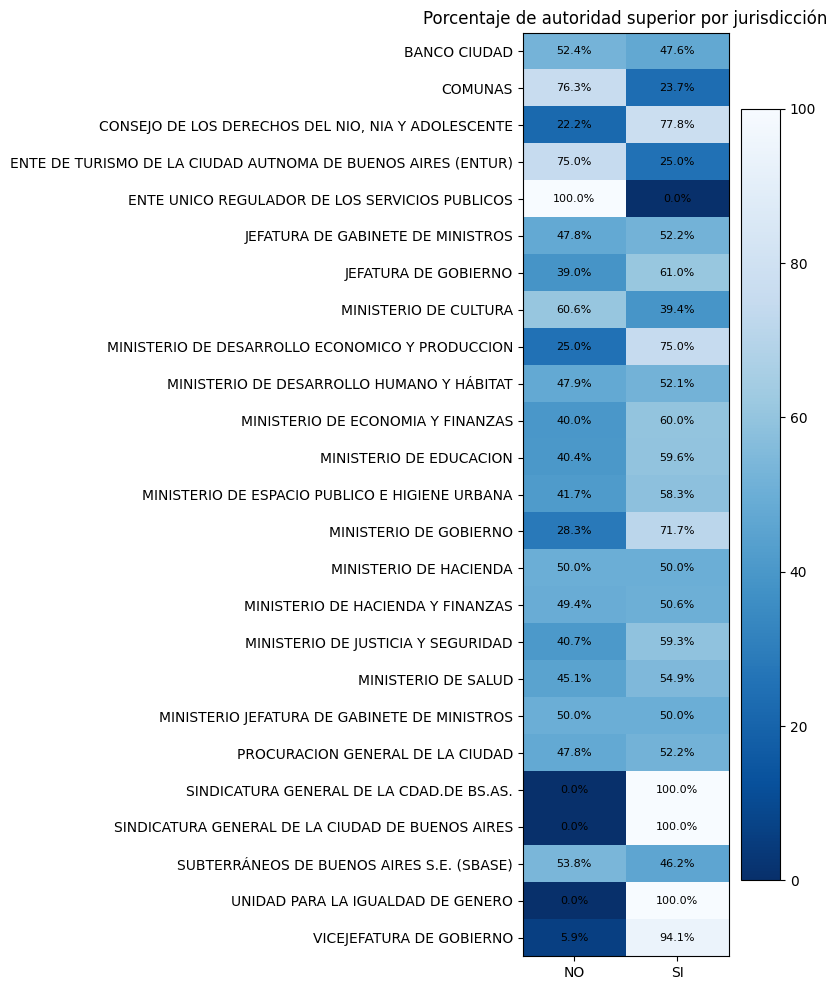

In [ ]:
tabla = pd.crosstab(
    df_limpio['jurisdiccion'],
    df_limpio['autoridad_superior'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(8, 10))

heatmap = ax.imshow(
    tabla,
    aspect='auto',
    cmap='Blues_r'
)

# etiquetas ejes
ax.set_xticks(range(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(range(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# texto dentro de celdas
for i in range(len(tabla.index)):
    for j in range(len(tabla.columns)):
        ax.text(
            j,
            i,
            f'{tabla.iloc[i, j]:.1f}%',
            ha='center',
            va='center',
            fontsize=8
        )

# barra de color
fig.colorbar(heatmap)

ax.set_title(
    'Porcentaje de autoridad superior por jurisdicción'
)

plt.tight_layout()
plt.show()

Después de observar ambos gráficos, se pueden sacar las siguientes conclusiones:

1. Existen jurisdicciones con una significativa cantidad de funcionarios (como la `JEFATURA DE GABINETE DE MINISTROS`, con más de 300). Otras, en cambio, apenas cuentan con uno solo (como el `ENTE UNICO REGULADOR DE LOS SERVICIOS PUBLICOS`).

2. No existe una distribución clara entre jurisdicciones respecto a los porcentajes de autoridades superiores, aunque sí se denota que, en la mayoría de los casos, superan el 50% del total de cada jurisdicción.

* Procedemos a hacer lo mismo graficos para los cargos.

In [ ]:
tabla = pd.crosstab(
    df_limpio['cargo'],
    df_limpio['autoridad_superior']
)

print(tabla)

autoridad_superior                                   NO   SI
cargo                                                       
ASESOR DE PLANTA DE GABINETE DE MINISTRO/ DE PR...  128    8
ASESOR/A DE PLANTA DE GABINETE O RGIMEN EQUIVAL...   11    3
AUDITOR                                               2   34
CARGO SUPERIOR A COMANDANTE (BOMBEROS)                8    6
CARGO SUPERIOR A COMISARIO                          100   96
CONTROLADOR DE FALTAS                                13   18
DIRECTOR GENERAL O EQUIVALENTE DEL PODER EJECUT...   86  567
DIRECTOR GENERAL/ DIRECTOR DE LA PROCURACIN GEN...   21   84
GERENTE / SUBGERENTE OPERATIVO                       98   10
GERENTE GENERAL Y SUBGERENTE GENERAL BANCO CIUDAD    10    5
INTEGRANTE  DE COMISIN EVALUADORA O DE COMISIN ...  256   10
JEFE DE GOBIERNO                                      0    1
JEFE DE LA POLICIA DE LA CIUDAD                       1    0
JEFE DEL CUERPO DE BOMBEROS DE LA CIUDAD              0    1
MIEMBRO JUNTA COMUNAL   

/tmp/ipykernel_2488/16288854.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


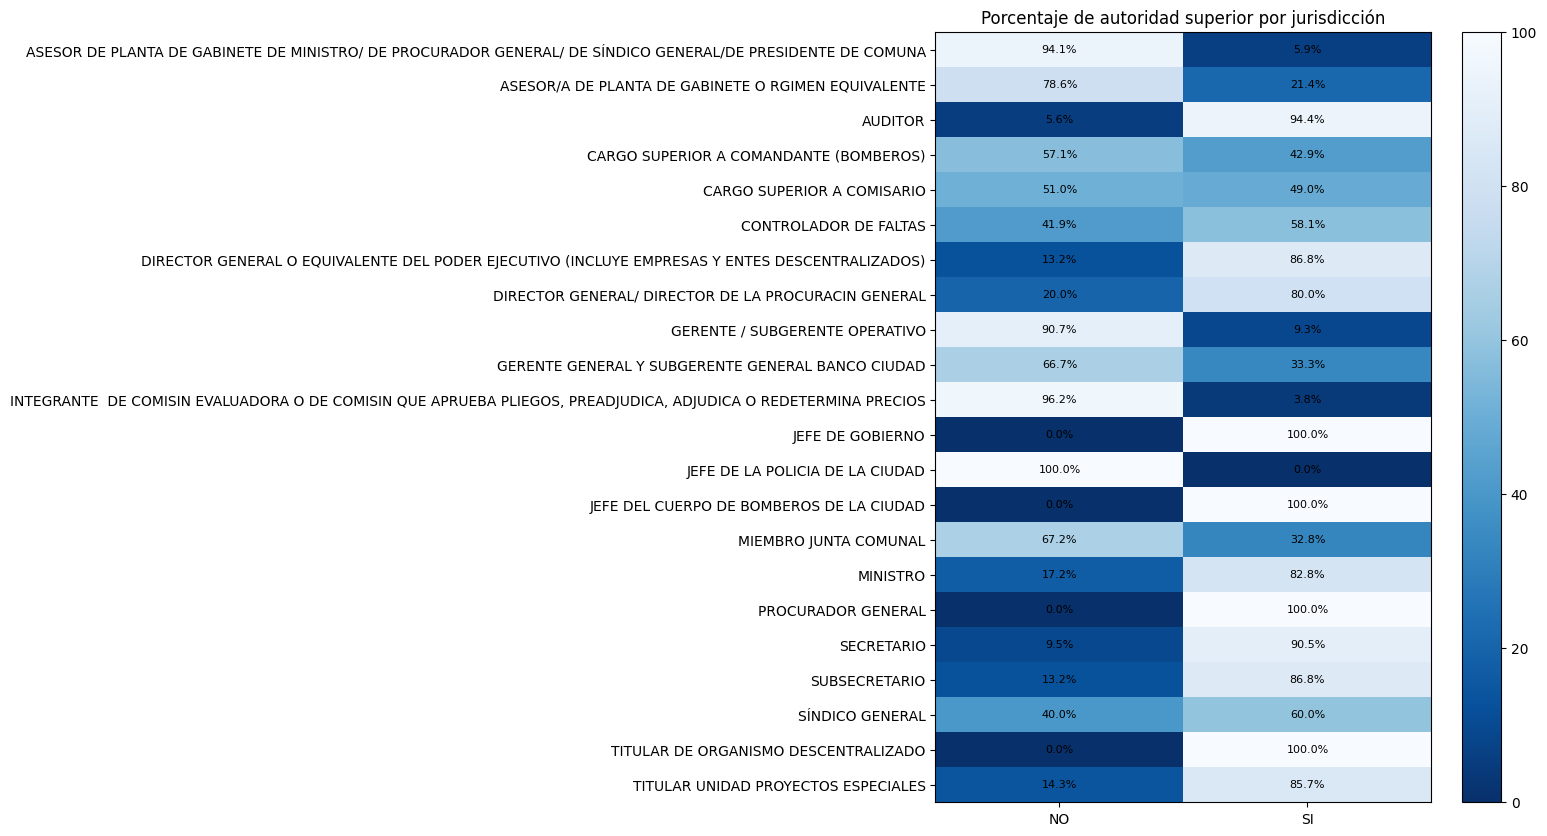

In [ ]:
tabla = pd.crosstab(
    df_limpio['cargo'],
    df_limpio['autoridad_superior'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(8, 10))

heatmap = ax.imshow(
    tabla,
    aspect='auto',
    cmap='Blues_r'
)

# etiquetas ejes
ax.set_xticks(range(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(range(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# texto dentro de celdas
for i in range(len(tabla.index)):
    for j in range(len(tabla.columns)):
        ax.text(
            j,
            i,
            f'{tabla.iloc[i, j]:.1f}%',
            ha='center',
            va='center',
            fontsize=8
        )

# barra de color
fig.colorbar(heatmap)

ax.set_title(
    'Porcentaje de autoridad superior por jurisdicción'
)

plt.tight_layout()
plt.show()

Después de observar ambos gráficos, se pueden sacar las siguientes conclusiones:

1. Existen jurisdicciones con una significativa cantidad de funcionarios (como la `DIRECTOR GENERAL O EQUIVALENTE DEL PODER EJECUTIVO`, con más de 600). Otras, en cambio, apenas cuentan con uno solo (como el `EJEFE DEL CUERPO DE BOMBEROS DE LA CIUDAD`).

2. A excepción de `CARGO SUPERIOR A COMANDANTE (BOMBEROS)`, `CARGO SUPERIOR A COMISARIO`, y `CONTROLADOR DE FALTAS`, el resto de los cargos presentan distribuciones que favorecen marcadamente a una de las dos categorías (ser o no autoridad superior), superando generalmente un ratio de 2/3 frente a 1/3.

* Finalmente, veremos la relación entre las variables numéricas, incluido el patrimonio total, con un heatmap.

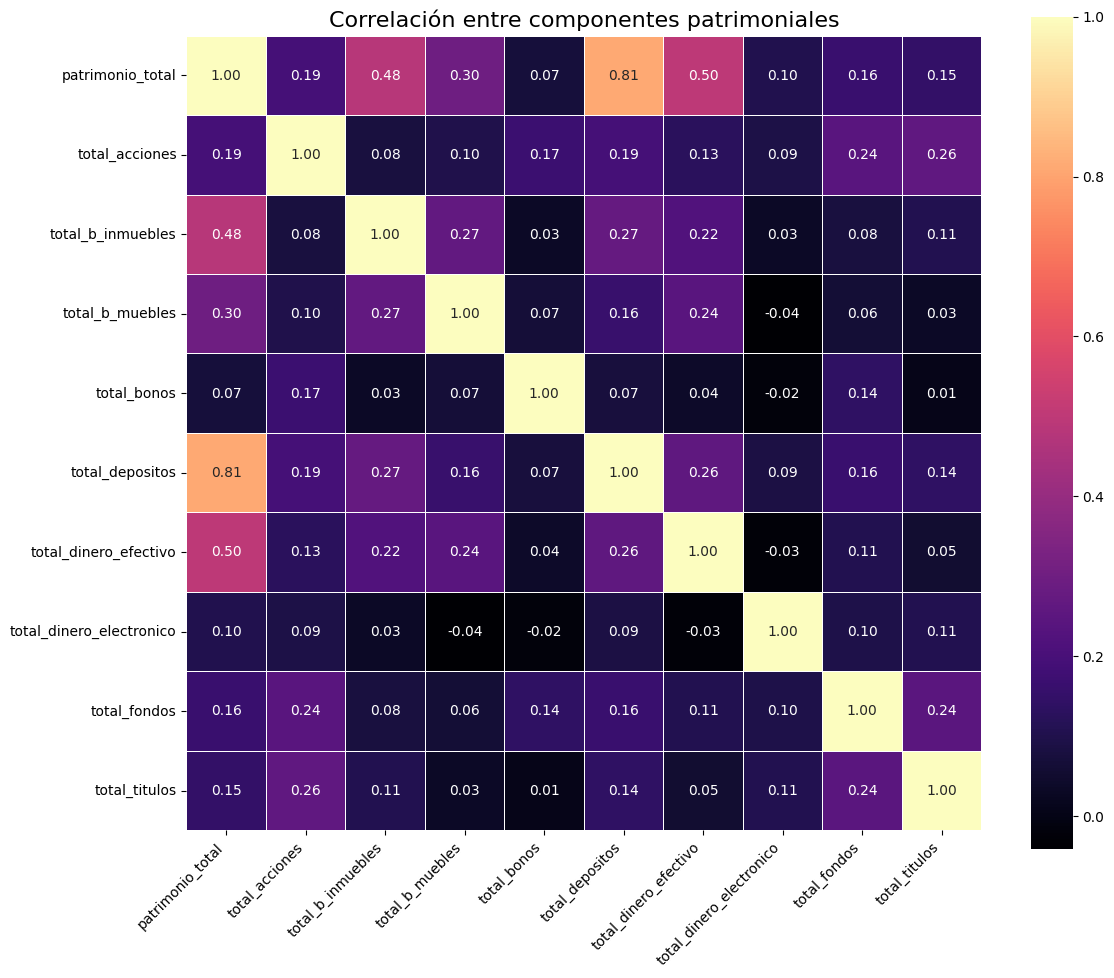

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# VARIABLES
# =========================

variables = [
    'patrimonio_total',
    'total_acciones',
    'total_b_inmuebles',
    'total_b_muebles',
    'total_bonos',
    'total_depositos',
    'total_dinero_efectivo',
    'total_dinero_electronico',
    'total_fondos',
    'total_titulos'
]

# =========================
# MATRIZ DE CORRELACION
# =========================

corr = df_limpio[variables].corr(
    method='spearman'
)

# =========================
# HEATMAP
# =========================

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='magma',
    square=True,
    linewidths=0.5
)

plt.title(
    'Correlación entre componentes patrimoniales',
    fontsize=16
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Después de estudiar el heatmap, podemos sacar las siguientes conclusiones:

1. El `patrimonio_total` tiene su correlación más fuerte con `total_depositos` (0,81), seguido por `total_dinero_efectivo` (0,50) y `total_b_inmuebles` (0,48). Esto sugiere que el patrimonio de los funcionarios está compuesto, principalmente, por depósitos bancarios y efectivo, más que por activos fijos o bonos.

2. Si bien los bienes inmuebles (`total_b_inmuebles`) tienen una correlación moderada con el patrimonio total (0,48), también tienen una relación casi nula con el dinero en efectivo (`total_dinero_efectivo`, 0,22) o bonos (`total_bonos`, 0,03). Esto refuerza la idea de que son variables independientes entre sí: tener muchas casas no implica necesariamente tener mucha plata en el banco.

3. Variables como `total_bonos`, `total_dinero_electronico` y `total_titulos` tienen correlaciones cercanas a 0 con casi todo. Esto significa que son activos muy específicos que solo poseen unos pocos, o que sus montos son tan pequeños que no mueven la aguja del patrimonio total.

### D. Visualizaciones

#### 1. Cantidad de Funcionarios Outliers por Jurisdicción

Para evaluar la concentración de riqueza primero visualizaremos la cantidad de funcionarios por encima del ya definido "límite superior", separados por jurisdicción.

In [ ]:
df_outliers = df_limpio[
    df_limpio['patrimonio_total'] > limite_superior
]

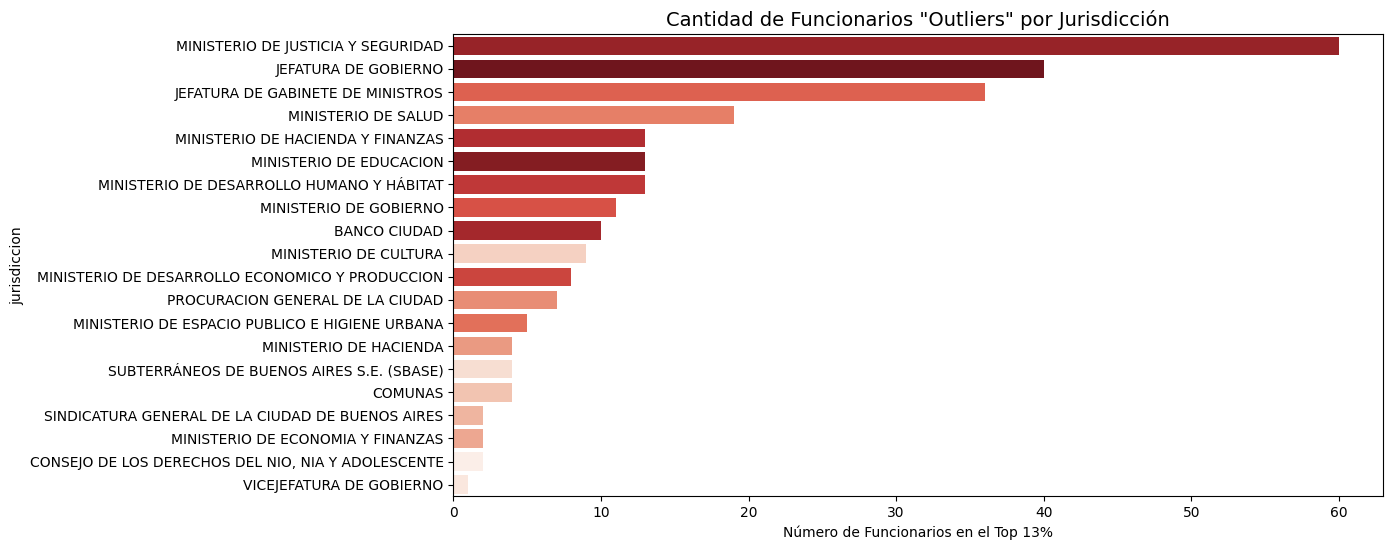

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(
    y='jurisdiccion',
    data=df_outliers,
    order=df_outliers['jurisdiccion'].value_counts().index,
    palette='Reds_r',
    hue='jurisdiccion',
    legend=False
)
plt.title('Cantidad de Funcionarios "Outliers" por Jurisdicción', fontsize=14)
plt.xlabel('Número de Funcionarios en el Top 13%')
plt.show()

De aquí podemos inferir que claramente hay algunas jurisdicciones que presentan una mayor cantidad de "outliers", como son el Ministerio de Justicia y Seguridad, la Jefatura de Gobierno y la Jefatura de Gabinete de Ministros. Sin embargo, este dato aislado es necesario compararlo con otras variables para poder extraer concluciones más útiles.

#### 2. Relación entre Patrimonio Mediano y Concentración de Outliers (Top 10)

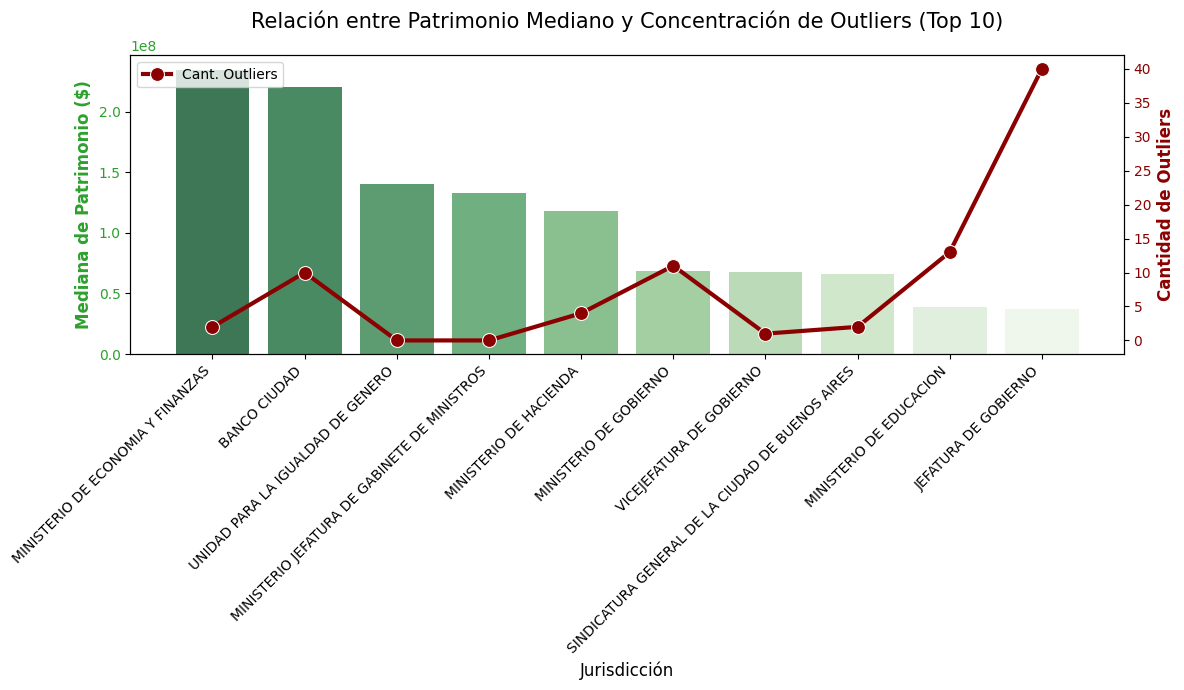

In [ ]:
resumen_juris = df_limpio.groupby('jurisdiccion')['patrimonio_total'].agg(['median', 'count'])

outliers_count = df_outliers['jurisdiccion'].value_counts()

df_analisis = pd.DataFrame({
    'mediana_patrimonio': resumen_juris['median'],
    'cant_outliers': outliers_count
}).fillna(0)

df_analisis = df_analisis.sort_values(by='mediana_patrimonio', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12, 7))

sns.barplot(
    x=df_analisis.index,
    y=df_analisis['mediana_patrimonio'],
    hue=df_analisis.index,
    ax=ax1,
    palette='Greens_r',
    alpha=0.8,
    legend=False
)
ax1.set_ylabel('Mediana de Patrimonio ($)', color='#2ca02c', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2ca02c')
ax1.set_xlabel('Jurisdicción', fontsize=12)

ax2 = ax1.twinx()

sns.lineplot(
    x=df_analisis.index,
    y=df_analisis['cant_outliers'],
    ax=ax2,
    color='darkred',
    marker='o',
    markersize=10,
    linewidth=3,
    label='Cant. Outliers'
)
ax2.set_ylabel('Cantidad de Outliers', color='darkred', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.grid(False)

plt.title('Relación entre Patrimonio Mediano y Concentración de Outliers (Top 10)', fontsize=15, pad=20)
ax1.set_xticks(range(len(df_analisis.index)))
ax1.set_xticklabels(df_analisis.index, rotation=45, ha='right')
fig.tight_layout()

plt.show()

Comparando la concentración de outliers con el patrimonio mediano podemos llegar a un descubrimiento interesante: las jurisdicciones con mayor cantidad de outliers no están dentro de las 9 con mayor mediana. Esto parecería indicar que estos outliers son muy dispersos y que hay una gran asimetría en dichas jurisdicciones. Hagamos ahora una comparativa con todas las jurisdicciones.

#### 3. Mediana de Patrimonio vs. Cantidad de Outliers

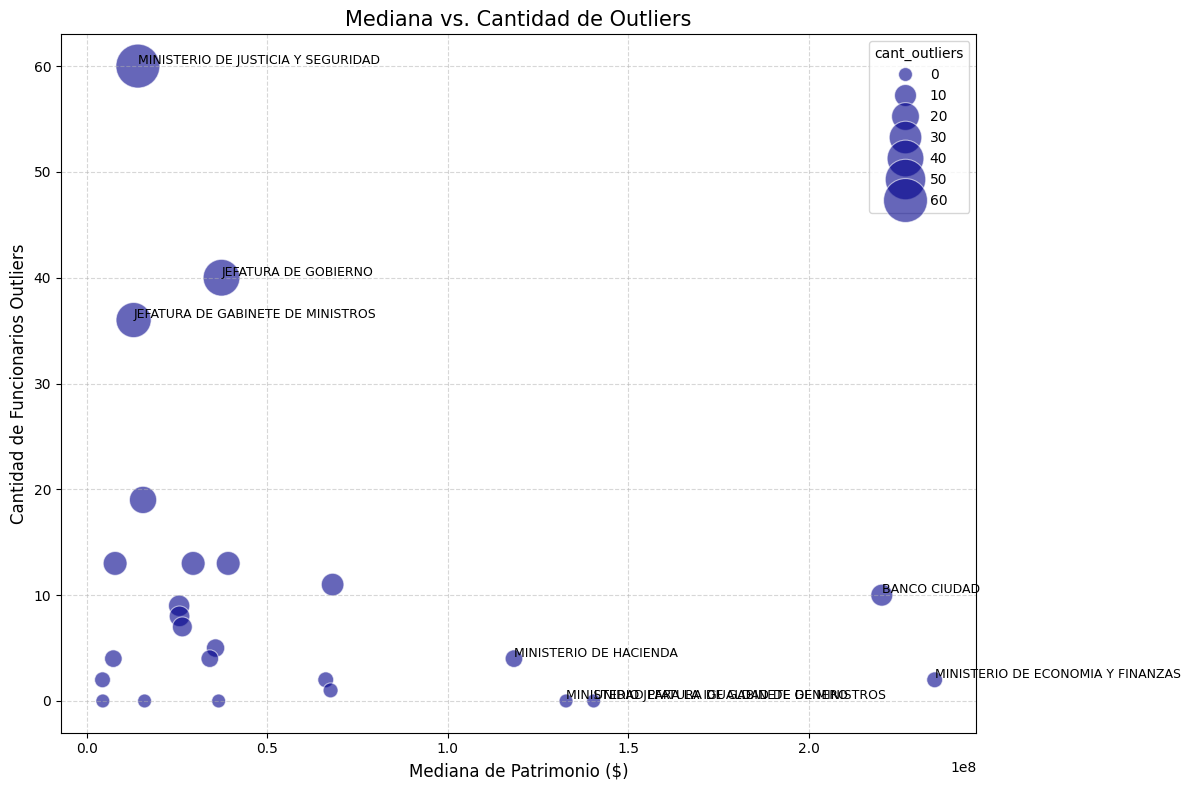

In [ ]:
resumen_completo = df_limpio.groupby('jurisdiccion')['patrimonio_total'].median().to_frame(name='mediana')
resumen_completo['cant_outliers'] = df_outliers['jurisdiccion'].value_counts()
resumen_completo = resumen_completo.fillna(0)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=resumen_completo,
    x='mediana',
    y='cant_outliers',
    size='cant_outliers',
    sizes=(100, 1000),
    alpha=0.6,
    color='darkblue'
)

for i in range(resumen_completo.shape[0]):
    if resumen_completo.cant_outliers.iloc[i] > resumen_completo.cant_outliers.mean() * 2 or \
       resumen_completo.mediana.iloc[i] > resumen_completo.mediana.median() * 2:
        plt.text(
            resumen_completo.mediana.iloc[i]+100,
            resumen_completo.cant_outliers.iloc[i]+0.2,
            resumen_completo.index[i],
            fontsize=9
        )

plt.title('Mediana vs. Cantidad de Outliers', fontsize=15)
plt.xlabel('Mediana de Patrimonio ($)', fontsize=12)
plt.ylabel('Cantidad de Funcionarios Outliers', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Este tercer gráfico afianza lo dicho en el anterior. Las 3 jurisdicciones con mayor cantidad de outliers no muestran valores "outliers" en cuanto a la media de los patrimonios, lo que muestra que estos outliers son muy atípicos incluso dentro de cada jurisdicción.

#### 4. Distribución del Tipo de Riqueza

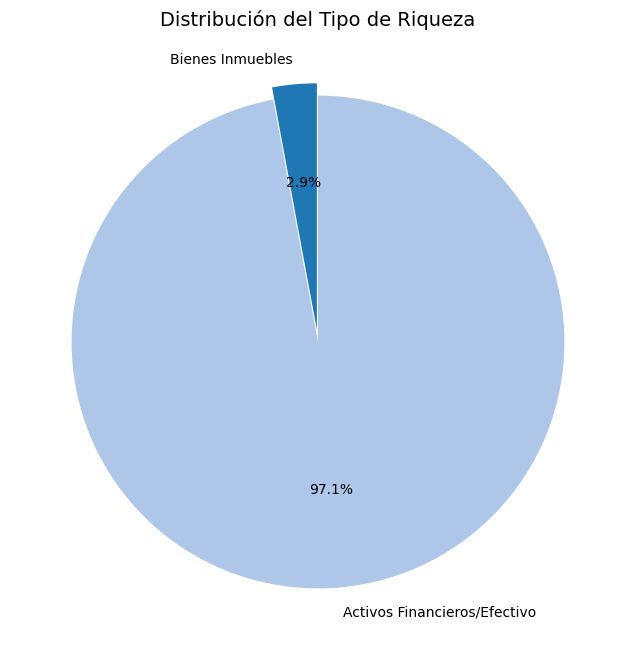

In [ ]:
total_inmuebles = df_limpio['total_b_inmuebles'].sum()
total_financiero = df_limpio[['total_acciones', 'total_bonos', 'total_depositos',
                              'total_dinero_efectivo', 'total_dinero_electronico',
                              'total_fondos', 'total_titulos']].sum().sum()

etiquetas = ['Bienes Inmuebles', 'Activos Financieros/Efectivo']
valores = [total_inmuebles, total_financiero]

plt.figure(figsize=(8, 8))
plt.pie(valores, labels=etiquetas, autopct='%1.1f%%', colors=['#1f77b4', '#aec7e8'],
        startangle=90, explode=(0.05, 0))
plt.title('Distribución del Tipo de Riqueza', fontsize=14)
plt.show()

Esta simple comparativa nos muestra una amplia preferencia hacie activos financieros y efectivo por sobre bienes inmuebles.

#### 5. Autoridades Superiores vs Otros Cargos

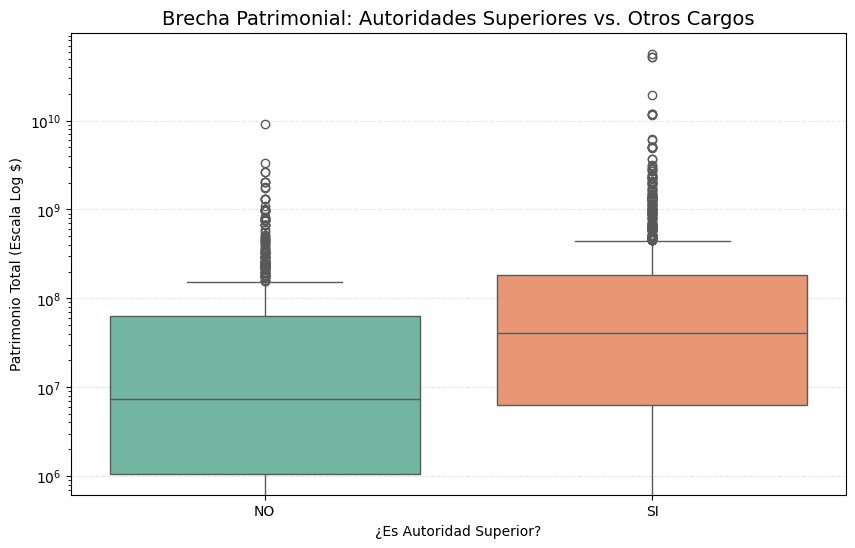

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='autoridad_superior',
    y='patrimonio_total',
    data=df_limpio,
    palette='Set2',
    hue='autoridad_superior'
)
plt.yscale('log')
plt.title('Brecha Patrimonial: Autoridades Superiores vs. Otros Cargos', fontsize=14)
plt.xlabel('¿Es Autoridad Superior?')
plt.ylabel('Patrimonio Total (Escala Log $)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Como era de esperarse, las autoridades superiores tienen un patrimonio total mayor que otros cargos. Para esta representación se eligió una escala logarítmica para evitar desviaciones visuales con respecto a los outliers, ya que en este caso solo nos interesa una visión global.

#### 6. Relación entre Inversión Inmobiliaria y Liquidez por Cargo

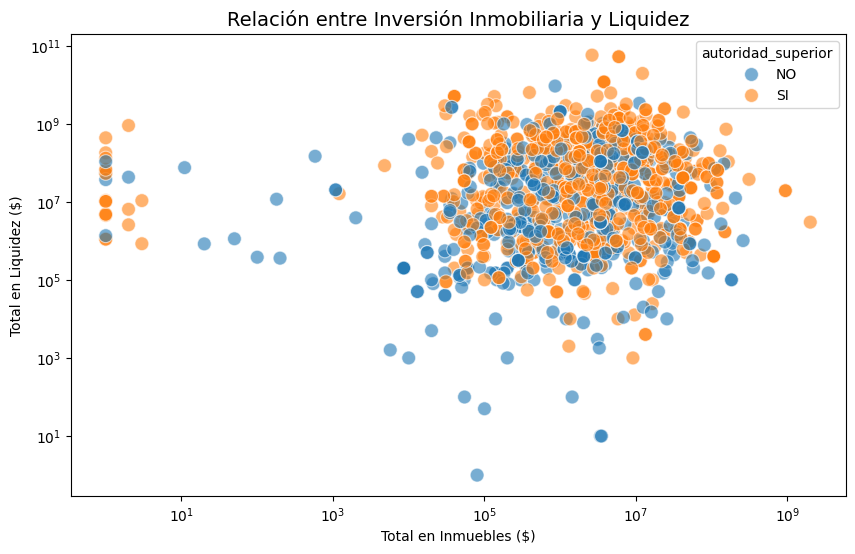

In [ ]:
df_limpio['liquidez_total'] = df_limpio[['total_dinero_efectivo', 'total_depositos', 'total_dinero_electronico']].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_limpio, x='total_b_inmuebles', y='liquidez_total',
                hue='autoridad_superior', alpha=0.6, s=100)

plt.title('Relación entre Inversión Inmobiliaria y Liquidez', fontsize=14)
plt.xlabel('Total en Inmuebles ($)')
plt.ylabel('Total en Liquidez ($)')
plt.xscale('log')
plt.yscale('log')
plt.show()

Combinando las últimas dos visualizaciones, podemos ver como cada tipo de cargo (aquí diferenciado entre "cargo superior" y "otros") maneja su patrimonio de forma distinta. Aunque la mayoría de los datos son similares para cada cargo, se nota que existen muchos cargos superiores que se enfocan más en la liquidez, mientras que hay un grupo de "otros cargos" que usan su patrimonio para la adquisición de inmuebles.

### E. Síntesis del EDA

A través del análisis exploratorio de datos (EDA), hemos podido observar las siguientes tendencias y/o patrones:

* El análisis revela una distribución de los patrimonios muy sesgada hacia una minoría que acumula enormes cantidades de poder adquisitivo.
* El patrimonio de los funcionarios parece presentar un sesgo muy marcado hacia la acumulación de dinero líquido, tanto en efectivo como en depósitos, por sobre bienes inmuebles u otros activos.
* No parece haber una distribución predilecta por variable, sino que se observan variaciones enormes en todas.
* Las autoridades superiores suelen tener más patrimonio que los subordinados (las medianas son, casi siempre, superiores) y, a su vez, suelen mostrar más variabilidad y cantidad de outliers (patrimonios extremadamente grandes).
* Existen cargos y jurisdicciones que agrupan cantidades significativas de funcionarios y otros casos donde apenas tienen un solo representante.

El EDA también parece ya haber aportado suficiente información como para responder a las preguntas objetivo del negocio:

1. ¿Cuáles son las jurisdicciones o ministerios que concentran a los funcionarios con el mayor patrimonio promedio?

* `MINISTERIO DE HACIENDA Y FINANZAS` y `MINISTERIO DE DESARROLLO ECONÓMICO Y PRODUCCIÓN` muestran no solo distribuciones altas, sino una relación equitativa, o incluso mayoritaria, de autoridades superiores.

* `JEFATURA DE GABINETE DE MINISTROS` es, tanto por su cantidad de funcionarios (más de 300) como por su distribución, el núcleo de concentración de patrimonios elevados.


* `BANCO CIUDAD` y `PROCURACIÓN GENERAL`, aunque tienen menos funcionarios, presentan **outliers** extremadamente altos que elevan el promedio de dichas jurisdicciones.

2. ¿Existe una brecha patrimonial medible y significativa entre los funcionarios catalogados como "Autoridad Superior" frente a los cargos subordinados?

* En casi todas las jurisdicciones, la mediana de las autoridades superiores está desplazada varios órdenes de magnitud por encima de los subordinados.

* Las autoridades superiores presentan, en una gran cantidad de jurisdicciones, una mayor cantidad de **outliers**, con patrimonios iguales o mucho más altos que los subordinados.

3. ¿Cuál es la distribución del tipo de riqueza (inmuebles vs. activos financieros/depósitos) en la clase política porteña?

* El `patrimonio_total` tiene una correlación de 0,81 con `total_depositos`. Esto define a la clase política no como poseedora de grandes extensiones de tierra, sino como ahorristas bancarizados.

* Aunque los bienes raíces son un pilar (`total_b_inmuebles`, 0,48), su peso es secundario frente al dinero líquido como el efectivo (`total_dinero_efectivo`, 0,50) y depósitos (`total_depositos`, 0,81).

* El resto de las variables numéricas, salvo `total_b_muebles` (0,30), tienen una presencia marginal.


A pesar de ello, se recomienda proseguir con el modelado por las siguientes razones:

* Se puede realizar una predicción del tipo y valor del patrimonio que tendrán futuros funcionarios en base a la jurisdicción, cargo y si son o no una autoridad superior.

* Se pueden obtener correlaciones más complejas entre variables, tanto de tipos categóricos como numéricos, como determinar si hay una propensión de un funcionario con cierto cargo o de cierta jurisdicción a tener un patrimonio de un tipo particular.

* Se pueden detectar anomalías que, ya sea por cargo y/o jurisdicción, superan con creces el patrimonio esperado para sus puestos.

* Se puede automatizar la generación de información, de tal forma que no se tenga que hacer un nuevo EDA cada vez que se quieran obtener resultados.

* Se puede escalar la generación de información de tal forma que se puedan procesar nuevos funcionarios, registros, autoridades y patrimonios.

En este caso, nos encontraríamos ante un caso en el que un modelo de regresión sería ideal, gracias a la existencia de la variable `patrimonio_total`, la cual sería el centro de cualquier hipótesis, tanto entre las variables numéricas que la componen como las categóricas con las que se tiene que relacionar.

Tomando en cuenta las enormes variaciones que se presentan en los datos:
- Diferencias enormes entre patrimonios.
- Cargos y jurisdicciones con apenas un funcionario.
- Distribuciones erráticas de autoridades superiores por cargo y jurisdicción.

El modelo adecuado, tanto por ser regresivo como por su integración a Google Colab, sería el modelo **Random Forest Regressor**. Aquí se listan las razones:

- Captura relaciones complejas entre variables, lo que permitirá observar nuevas interacciones entre los datos que no se podrían observar con un EDA.
- Maneja bien los outliers y distribuciones anómalas, lo cual es útil ante las enormes diferencias entre patrimonios y su variabilidad.
- Reduce el ruido que puede generar casos excepcionales como jurisdicciones o cargos con pocos funcionarios que los representen y distribuciones desiguales de autoridades superiores.
- Funciona bien tanto con variables numéricas como categóricas.
- Es de fácil implementación, gracias a la librería **scikit-learn** de Python.

### Video Entrega 2:
https://youtu.be/3c65mIGuB4o

## Entrega 3: Enfoque de Modelado

### 1. Decisión sobre el modelado

En base a los aportes del EDA, se considera que, si bien se observa una inherente complejidad en los datos elegidos, existen relaciones entre las variables que pueden ayudar a la construcción de un modelo que prediga los patrimonios de funcionarios en base a las categorías que presenten.

* **Pregunta objetivo del modelado:** ¿En qué medida las características institucionales y de jerarquía de un funcionario público (jurisdicción, cargo, autoridad superior) permiten estimar o predecir su patrimonio total declarado?
* **Aporte del EDA:** el análisis exploratorio de datos (EDA) demostró que el patrimonio no se distribuye de manera aleatoria ni lineal. El uso de visualizaciones con escala simétrica logarítmica (`symlog`) evidenció la existencia de asimetrías marcadas según la dependencia institucional. Dado que los métodos estadísticos tradicionales (como promedios o regresiones lineales simples) fallan al intentar capturar interacciones cuando existe una **enorme variedad de opciones y categorías distintas** (múltiples cargos y jurisdicciones), un modelo de aprendizaje automático puede descubrir patrones multidimensionales ocultos que un EDA no podría encontrar.

### 2. Tipo de modelo
En base a los estudios realizados durante el EDA, se considera que el tipo de aprendizaje automático debe ser del tipo **Regresión** y **Supervisado**, por las siguientes razones:

  1. **Finalidad Predictiva del Proyecto:** el objetivo del negocio no es descubrir estructuras ocultas o agrupar los datos a ciegas (**Aprendizaje No Supervisado**, como el **Clustering**), sino construir un modelo predictivo capaz de estimar con la mayor precisión posible una variable numérica continua a partir de nuevos datos categóricos.

  2. **Existencia de una Variable Objetivo:** para cada combinación de categorías (`cargo`, `jurisdiccion`), conocemos de antemano el resultado real (`patrimonio_total`). Un modelo de **Aprendizaje Supervisado** requiere de una *etiqueta* para poder contrastar sus predicciones con los casos reales, permitiéndole entrenarse minimizando el error entre sus predicciones y los valores verdaderos.

  3. **Tipo de la Variable Objetivo:** la variable que se intenta estimar o predecir, `patrimonio_total`, es numérica continua (valores monetarios netos), lo que descarta de forma directa la **Clasificación** (variables categóricas) y nos lleva directo hacia la **Regresión**.


### 3. Variable Objetivo
* **Variable Objetivo:** `patrimonio_total` (variable numérica continua).
* **Justificación desde el EDA:** es una variable sintética, creada para ser la acumulación de todos los tipos de patrimonios de los funcionarios. El análisis multivariado demostró que esta variable sintetiza eficazmente este rol. A su vez, la alta variabilidad y asimetría de sus valores, tanto en el caso general como en los particulares (combinación de variables categóricas), precisamente justifican su elección: es el objeto de estudio ideal para este proyecto. Finalmente, la variable demostró que, si bien no existen relaciones lineales, tampoco hay una aleatoriedad en sus valores: existe una correlación entre esta y los distintos cargos, jurisdicciones y jerarquía de los funcionarios.

### 4. Limitaciones, riesgos y pasos adicionales recomendados

A pesar de la viabilidad del modelado, el grupo identifica las siguientes limitaciones y riesgos:
* **Outliers**: se pudo identificar la presencia de un número significativo de outliers, variando pronunciadamente en cantidad y patrimonio en base a cada combinación posible de categorías. Esta dispersión provoca que cualquier medida de centralización y variación aplicada de forma general sea insuficiente para describir o predecir la realidad descrita por los datos.
* **Fuga de Datos:** existe un riesgo crítico si se incluyen a las variables numéricas originales (`total_b_inmuebles`, `total_depositos`, etc.) como variables predictoras, dado que la variable objetivo es la suma directa de estos elementos.
* **Alta variación de funcionarios por categoría:** las variables categóricas `jurisdiccion` y `cargo` poseen una gran variabilidad en la cantidad de funcionarios (algunas solo tienen uno, otras cientos), lo que puede provocar ruido estadístico.
* **Sesgo por Valores Extremos:** el enorme rango de los patrimonios, algunos en el orden de los miles de millones, puede distorsionar severamente las métricas de centralización y variabilidad generales y específicas.

**Pasos adicionales obligatorios antes de implementar el modelo:**
1. **Elección de variables:** excluir todos los subtotales financieros del conjunto de variables predictoras, entrenando el modelo únicamente con variables categóricas (`cargo`, `jurisdiccion` y `autoridad_superior`).
2. **Transformación de las variables categóricas:** se recomienda agrupar los registros de las categorías con pocos funcionarios en una nueva categoría. Por ejemplo: "Otros". Así, se mitigaría la dispersión provocada por la excesiva cantidad de opciones con baja frecuencia de funcionarios.
3. **Escalado de la Variable Objetivo:** transformación logarítmica durante el entrenamiento para estabilizar la varianza y mitigar la asimetría observada en los boxplots.

### 5. Reflexión Final

Como grupo, esta entrega significó nuestro primer contacto práctico con la metodología **CRISP-DM**. Si tuviéramos que sintetizar las lecciones más valiosas de este recorrido, destacaríamos tres pilares:

1. **La comprensión del negocio y los datos:** este proyecto comenzó con un dilema: encontrar un conjunto de datos que pudiera ser útil para explorar durante la cátedra. Tras evaluar distintos datasets, encontramos que el mercado inmobiliario era un sujeto ideal para un estudio riguroso. Luego, ya habiendo encontrado un conjunto de datos útil para la cátedra, realizamos una exploración superficial y seleccionamos los objetivos del negocio en base a esta observación inicial.

2. **El EDA:** al comienzo, tomamos la que sería la decisión más importante del proyecto: acumular los montos de los subtipos de patrimonios distintos en una nueva variable numérica, `patrimonio_total`, la cual haría las veces de variable objetivo. Esta nueva variable daría un nuevo sentido al EDA: explorar la relación que `patrimonio_total` tiene con las variables categóricas `cargo`, `jurisdiccion` y `autoridad_superior`. Con este enfoque, pudimos observar las enormes asimetrías en los datos, pero también comprobar la existencia de estas relaciones entre la variable objetivo y las tres categóricas. Finalmente, el EDA nos sorprendió al responder las preguntas realizadas durante la etapa de comprensión de negocio. A pesar de ello, y gracias a `patrimonio_total`, determinamos que era posible proseguir con el modelado.

3. **Fundamentación en la elección del modelo:** a pesar de que los objetivos de negocio ya se podían considerar como cumplidos, el EDA también demostró que sí existían relaciones entre las variables que podían servir para implementar un modelo predictivo. Usando a `patrimonio_total` como etiqueta, era posible implementar un modelo de **Aprendizaje Supervisado** y, tomando en cuenta que dicha variable objetivo es del tipo numérica continua, el tipo de modelo debería ser de **Regresion**. Finalmente, habiendo observado la complejidad en las relaciones de los datos y la importancia de outliers para el caso de estudio, se propuso a **Random Forest Regressor**, tanto por su robustez para tratar con anomalías como por su integración con Google Colab y Python.




En conclusión, este proyecto se caracterizó por la necesidad constante de adaptarnos a la realidad presentada por los datos, cambiar nuestra perspectiva del sujeto de estudio y ajustar nuestros procedimientos a medida que avanzábamos por las distintas etapas del CRISP-DM.

### Video Entrega 3:

[https://youtu.be/YpBtpTkgy6k](https://youtu.be/YpBtpTkgy6k)